In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Daily Data Analysis

In [62]:
a_daily_data = pd.read_csv("Dhyey/A-Daily.csv")

In [63]:
# Shape of the dataset
print("Shape of the dataset:", a_daily_data.shape) # (number of rows, number of columns)

Shape of the dataset: (731, 5)


In [64]:
# Overview of the dataset
print("--------------------- First 5 rows of the dataset -----------------------")
print(a_daily_data.head()) # prints first 5 rows of the dataset

--------------------- First 5 rows of the dataset -----------------------
           Date Call Volume     CCT Service Level Abandon Rate
0  01/01/24 Mon       2,147  302.45        98.55%        0.37%
1  01/02/24 Tue       7,458  349.22        52.13%       11.36%
2  01/03/24 Wed       6,882  331.07        70.46%        4.32%
3  01/04/24 Thu       6,208  341.80        72.00%        4.03%
4  01/05/24 Fri       6,190  334.56        80.63%        2.91%


In [65]:
print("--------------------- Dataset Info -----------------------")

print(a_daily_data.info()) # information related to column, non null counts, count type and dtypes.

--------------------- Dataset Info -----------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           731 non-null    object 
 1   Call Volume    707 non-null    object 
 2   CCT            707 non-null    float64
 3   Service Level  706 non-null    object 
 4   Abandon Rate   701 non-null    object 
dtypes: float64(1), object(4)
memory usage: 28.7+ KB
None


In [66]:
# Missing Values Count

print("--------------------- Missing Values count -----------------------")
print(a_daily_data.isna().sum().sort_values()) # counting missing values in each column and sorting them in ascending order.

--------------------- Missing Values count -----------------------
Date              0
Call Volume      24
CCT              24
Service Level    25
Abandon Rate     30
dtype: int64


In [67]:
# Unique values counts

print("--------------------- Unique Values count -----------------------")
print(a_daily_data.nunique().sort_values()) # counting unique values in each column and sorting them in ascending order.

--------------------- Unique Values count -----------------------
Abandon Rate     230
Service Level    551
Call Volume      642
CCT              665
Date             731
dtype: int64


In [69]:
# ---------- helper to clean numeric-looking strings ----------

def clean_numeric(series, percent=False):
    s = series.astype(str).str.strip()
    s = s.replace({
        "": np.nan, "nan": np.nan, "None": np.nan, "NA": np.nan, "N/A": np.nan, "-": np.nan
    })
    s = s.str.replace(",", "", regex=False)
    if percent:
        s = s.str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

# ---------- month mapper ----------
month_map = {
    "JAN": 1, "FEB": 2, "MAR": 3, "APR": 4, "MAY": 5, "JUN": 6,
    "JUL": 7, "AUG": 8, "SEP": 9, "OCT": 10, "NOV": 11, "DEC": 12
}

In [70]:
# copy original
a_daily = a_daily_data.copy()

# clean column names
a_daily.columns = a_daily.columns.str.strip()

# parse date
a_daily["Date"] = pd.to_datetime(a_daily["Date"], errors="coerce")

# convert numeric columns
a_daily["Call Volume"] = clean_numeric(a_daily["Call Volume"])
a_daily["CCT"] = clean_numeric(a_daily["CCT"])
a_daily["Service Level"] = clean_numeric(a_daily["Service Level"], percent=True)
a_daily["Abandon Rate"] = clean_numeric(a_daily["Abandon Rate"], percent=True)

# sort by date
a_daily = a_daily.sort_values("Date").reset_index(drop=True)

print("Shape:", a_daily.shape)
print("\nDtypes:\n", a_daily.dtypes)
print("\nMissing %:\n", (a_daily.isna().mean() * 100).round(2))
print("\nDuplicate dates:", a_daily["Date"].duplicated().sum())
print("\nDate range:", a_daily["Date"].min(), "to", a_daily["Date"].max())

Shape: (731, 5)

Dtypes:
 Date             datetime64[ns]
Call Volume             float64
CCT                     float64
Service Level           float64
Abandon Rate            float64
dtype: object

Missing %:
 Date             0.00
Call Volume      3.28
CCT              3.28
Service Level    3.42
Abandon Rate     4.10
dtype: float64

Duplicate dates: 0

Date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00


/tmp/ipykernel_408/997941082.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  a_daily["Date"] = pd.to_datetime(a_daily["Date"], errors="coerce")


In [88]:
a_daily = a_daily_data.copy()

# ---------- clean columns ----------
a_daily.columns = a_daily.columns.str.strip()

# ---------- parse date ----------
a_daily["Date"] = pd.to_datetime(a_daily["Date"], errors="coerce")

# ---------- helper for numeric cleaning ----------
def clean_numeric(series, percent=False):
    s = series.astype(str).str.strip()
    s = s.replace({
        "": np.nan, "nan": np.nan, "None": np.nan, "NA": np.nan, "N/A": np.nan, "-": np.nan
    })
    s = s.str.replace(",", "", regex=False)
    if percent:
        s = s.str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

# ---------- convert numeric columns ----------
a_daily["Call Volume"] = clean_numeric(a_daily["Call Volume"])
a_daily["CCT"] = clean_numeric(a_daily["CCT"])
a_daily["Service Level"] = clean_numeric(a_daily["Service Level"], percent=True)
a_daily["Abandon Rate"] = clean_numeric(a_daily["Abandon Rate"], percent=True)

# ---------- sort ----------
a_daily = a_daily.sort_values("Date").reset_index(drop=True)

# ---------- preserve raw missing flags ----------
for col in ["Call Volume", "CCT", "Service Level", "Abandon Rate"]:
    a_daily[f"{col}_was_missing"] = a_daily[col].isna().astype(int)

# ---------- inspect consecutive missing gaps ----------
print("Missing counts:\n", a_daily[["Call Volume", "CCT", "Service Level", "Abandon Rate"]].isna().sum())

# ---------- interpolate small gaps ----------
a_daily["Call Volume"] = a_daily["Call Volume"].interpolate(method="linear", limit_direction="both")
a_daily["CCT"] = a_daily["CCT"].interpolate(method="linear", limit_direction="both")
a_daily["Abandon Rate"] = a_daily["Abandon Rate"].interpolate(method="linear", limit_direction="both")
a_daily["Service Level"] = a_daily["Service Level"].interpolate(method="linear", limit_direction="both")

# ---------- enforce valid bounds ----------
a_daily["Call Volume"] = a_daily["Call Volume"].clip(lower=0)
a_daily["CCT"] = a_daily["CCT"].clip(lower=0)
a_daily["Abandon Rate"] = a_daily["Abandon Rate"].clip(lower=0)
a_daily["Service Level"] = a_daily["Service Level"].clip(lower=0, upper=100)

print("\nRemaining missing values after interpolation:")
print(a_daily[["Call Volume", "CCT", "Service Level", "Abandon Rate"]].isna().sum())

Missing counts:
 Call Volume      24
CCT              24
Service Level    25
Abandon Rate     30
dtype: int64

Remaining missing values after interpolation:
Call Volume      0
CCT              0
Service Level    0
Abandon Rate     0
dtype: int64


/tmp/ipykernel_408/893100357.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  a_daily["Date"] = pd.to_datetime(a_daily["Date"], errors="coerce")


In [89]:
cols = ["Call Volume", "CCT", "Service Level", "Abandon Rate"]

for col in cols:
    temp = a_daily[["Date", col]].copy()
    temp["is_missing"] = temp[col].isna().astype(int)

    groups = (temp["is_missing"] != temp["is_missing"].shift()).cumsum()
    streaks = temp.groupby(groups)["is_missing"].agg(["first", "size"])
    missing_streaks = streaks[streaks["first"] == 1]

    print(f"\n{col} missing streaks:")
    print(missing_streaks.head(10))


Call Volume missing streaks:
Empty DataFrame
Columns: [first, size]
Index: []

CCT missing streaks:
Empty DataFrame
Columns: [first, size]
Index: []

Service Level missing streaks:
Empty DataFrame
Columns: [first, size]
Index: []

Abandon Rate missing streaks:
Empty DataFrame
Columns: [first, size]
Index: []


In [91]:
# Save the cleaned CSV file

a_daily[a_daily_data.columns].to_csv("Dhyey/A-Daily_Cleaned.csv", index=False)

In [92]:
print("Shape of the dataset:", a_daily.shape) # (number of rows, number of columns)

Shape of the dataset: (731, 9)


### Interval Data Analysis

In [3]:
a_interval_data = pd.read_csv("Dhyey/A_Interval.csv")

In [4]:
# Shape of the dataset
print("Shape of the dataset:", a_interval_data.shape) # (number of rows, number of columns)

Shape of the dataset: (4084, 8)


In [5]:
# Overview of the dataset
print("--------------------- First 5 rows of the dataset -----------------------")
print(a_interval_data.head()) # prints first 5 rows of the dataset

--------------------- First 5 rows of the dataset -----------------------
   Month  Day Interval Service Level  Call Volume  Abandoned Calls  \
0  April  1.0     0:00       100.00%          5.0              0.0   
1  April  1.0     0:30       100.00%          5.0              0.0   
2  April  1.0     1:00       100.00%          4.0              0.0   
3  April  1.0     1:30       100.00%          3.0              0.0   
4  April  1.0     2:00       100.00%          1.0              0.0   

  Abandoned Rate     CCT  
0          0.00%   137.6  
1          0.00%   263.4  
2          0.00%  333.25  
3          0.00%     170  
4          0.00%     667  


In [6]:
print("--------------------- Dataset Info -----------------------")

print(a_interval_data.info()) # information related to column, non null counts, count type and dtypes.

--------------------- Dataset Info -----------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4084 entries, 0 to 4083
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Month            4083 non-null   object 
 1   Day              4083 non-null   float64
 2   Interval         4076 non-null   object 
 3   Service Level    3938 non-null   object 
 4   Call Volume      3995 non-null   float64
 5   Abandoned Calls  3977 non-null   float64
 6   Abandoned Rate   3919 non-null   object 
 7   CCT              3916 non-null   object 
dtypes: float64(3), object(5)
memory usage: 255.4+ KB
None


In [7]:
# Missing Values Count

print("--------------------- Missing Values count -----------------------")
print(a_interval_data.isna().sum().sort_values()) # counting missing values in each column and sorting them in ascending order.

--------------------- Missing Values count -----------------------
Month                1
Day                  1
Interval             8
Call Volume         89
Abandoned Calls    107
Service Level      146
Abandoned Rate     165
CCT                168
dtype: int64


In [8]:
# Unique values counts

print("--------------------- Unique Values count -----------------------")
print(a_interval_data.nunique().sort_values()) # counting unique values in each column and sorting them in ascending order.

--------------------- Unique Values count -----------------------
Month                 3
Abandoned Calls      21
Day                  31
Interval             48
Call Volume         296
Abandoned Rate      381
Service Level      1016
CCT                3297
dtype: int64


In [9]:
a_int = a_interval_data.copy()
a_int.columns = a_int.columns.str.strip()

def clean_numeric(series, percent=False):
    s = series.astype(str).str.strip()
    s = s.replace({
        "": np.nan, "nan": np.nan, "None": np.nan,
        "NA": np.nan, "N/A": np.nan, "-": np.nan
    })
    s = s.str.replace(",", "", regex=False)
    if percent:
        s = s.str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

month_map = {
    "JAN": 1, "JANUARY": 1,
    "FEB": 2, "FEBRUARY": 2,
    "MAR": 3, "MARCH": 3,
    "APR": 4, "APRIL": 4,
    "MAY": 5,
    "JUN": 6, "JUNE": 6,
    "JUL": 7, "JULY": 7,
    "AUG": 8, "AUGUST": 8,
    "SEP": 9, "SEPT": 9, "SEPTEMBER": 9,
    "OCT": 10, "OCTOBER": 10,
    "NOV": 11, "NOVEMBER": 11,
    "DEC": 12, "DECEMBER": 12
}

# preserve original missing flags for analysis
for col in ["Call Volume", "Abandoned Calls", "Abandoned Rate", "CCT", "Service Level"]:
    a_int[f"{col}_was_missing"] = a_int[col].isna().astype(int)

# normalize key columns
a_int["Month"] = a_int["Month"].astype("string").str.strip().str.upper()
a_int["Month"] = a_int["Month"].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA})

a_int["Day"] = pd.to_numeric(a_int["Day"], errors="coerce")

a_int["Interval"] = a_int["Interval"].astype("string").str.strip()
a_int["Interval"] = a_int["Interval"].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA})

# since Month/Day missing is tiny, carry forward/backward is reasonable
a_int["Month"] = a_int["Month"].ffill().bfill()
a_int["Day"] = a_int["Day"].ffill().bfill()

a_int["Month_num"] = a_int["Month"].map(month_map)

# parse interval
interval_dt = pd.to_datetime(a_int["Interval"], format="%H:%M", errors="coerce")
if interval_dt.isna().any():
    interval_dt_fallback = pd.to_datetime(a_int["Interval"], errors="coerce")
    interval_dt = interval_dt.fillna(interval_dt_fallback)

a_int["slot"] = ((interval_dt.dt.hour * 60 + interval_dt.dt.minute) // 30)
a_int["Hour"] = interval_dt.dt.hour
a_int["Minute"] = interval_dt.dt.minute

# drop rows where interval cannot be placed in the day
a_int = a_int[a_int["slot"].between(0, 47, inclusive="both")].copy()

# convert metrics
a_int["Service Level"] = clean_numeric(a_int["Service Level"], percent=True)
a_int["Call Volume"] = clean_numeric(a_int["Call Volume"])
a_int["Abandoned Calls"] = clean_numeric(a_int["Abandoned Calls"])
a_int["Abandoned Rate"] = clean_numeric(a_int["Abandoned Rate"], percent=True)
a_int["CCT"] = clean_numeric(a_int["CCT"])

# enforce valid ranges
for col in ["Call Volume", "Abandoned Calls", "CCT"]:
    a_int.loc[a_int[col] < 0, col] = np.nan

for col in ["Service Level", "Abandoned Rate"]:
    a_int.loc[(a_int[col] < 0) | (a_int[col] > 100), col] = np.nan

a_int.loc[a_int["Abandoned Calls"] > a_int["Call Volume"], "Abandoned Calls"] = np.nan
a_int.loc[a_int["Abandoned Calls"] > a_int["Call Volume"], "Abandoned Rate"] = np.nan

# logical reconstruction before generic imputation
mask_rate = (
    a_int["Abandoned Rate"].isna() &
    a_int["Abandoned Calls"].notna() &
    a_int["Call Volume"].gt(0)
)
a_int.loc[mask_rate, "Abandoned Rate"] = (
    a_int.loc[mask_rate, "Abandoned Calls"] / a_int.loc[mask_rate, "Call Volume"] * 100
)

mask_calls = (
    a_int["Abandoned Calls"].isna() &
    a_int["Abandoned Rate"].notna() &
    a_int["Call Volume"].notna()
)
a_int.loc[mask_calls, "Abandoned Calls"] = np.round(
    a_int.loc[mask_calls, "Abandoned Rate"] / 100 * a_int.loc[mask_calls, "Call Volume"]
)

a_int = a_int.sort_values(["Month_num", "Day", "slot"]).reset_index(drop=True)

print("Shape after prep:", a_int.shape)
print("\nMissing % after prep:")
print((a_int[["Month", "Day", "Interval", "Call Volume", "Abandoned Calls", "Abandoned Rate", "CCT", "Service Level"]]
       .isna().mean() * 100).round(2))

Shape after prep: (4076, 17)

Missing % after prep:
Month              0.00
Day                0.00
Interval           0.00
Call Volume        1.99
Abandoned Calls    2.38
Abandoned Rate     3.43
CCT                3.93
Service Level      3.39
dtype: float64


/tmp/ipykernel_14530/3879982825.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  interval_dt_fallback = pd.to_datetime(a_int["Interval"], errors="coerce")


In [51]:
# Delete missing rows in an interval

# keep only rows 0 to 4083
# a_interval_clean = b_daily_data.iloc[:4084].copy()

# save cleaned file
# a_interval_clean.to_csv("A_Interval.csv", index=False)

#print("Old shape:", b_daily_data.shape)
#print("New shape:", a_interval_clean.shape)
#print(a_interval_clean.tail())

Old shape: (8735, 8)
New shape: (4084, 8)
     Month   Day Interval Service Level  Call Volume  Abandoned Calls  \
4079  June  30.0    22:00       100.00%         23.0              0.0   
4080  June  30.0    22:30        83.33%         13.0              1.0   
4081  June  30.0    23:00        80.00%         10.0              0.0   
4082  June  30.0    23:30       100.00%         13.0              0.0   
4083   NaN   NaN      NaN           NaN          NaN              NaN   

     Abandoned Rate     CCT  
4079          0.00%  300.22  
4080          7.69%   189.5  
4081          0.00%   323.1  
4082          0.00%  247.46  
4083            NaN     NaN  


In [10]:
# duplicate key check

dup_count = a_int.duplicated(subset=["Month_num", "Day", "slot"]).sum()
print("Duplicate Month-Day-slot rows:", dup_count)

# how many intervals per day
intervals_per_day = (
    a_int.groupby(["Month_num", "Day"])["slot"]
         .nunique()
         .rename("interval_count")
         .sort_values()
)

print("\nIntervals per day summary:")
print(intervals_per_day.describe())

print("\nDays with fewer than 48 intervals:")
print(intervals_per_day[intervals_per_day < 48])

# missingness by slot
slot_missing_pct = (
    a_int.groupby("slot")[["Call Volume", "Abandoned Calls", "Abandoned Rate", "CCT", "Service Level"]]
         .apply(lambda x: x.isna().mean() * 100)
)

print("\nMissing % by slot:")
print(slot_missing_pct.head(10))

# range checks
print("\nRange summary:")
print(a_int[["Call Volume", "Abandoned Calls", "Abandoned Rate", "CCT", "Service Level"]].describe())

Duplicate Month-Day-slot rows: 0

Intervals per day summary:
count    91.000000
mean     44.791209
std       1.906227
min      38.000000
25%      43.000000
50%      45.000000
75%      46.000000
max      48.000000
Name: interval_count, dtype: float64

Days with fewer than 48 intervals:
Month_num  Day 
4          7.0     38
5          11.0    40
4          20.0    41
           13.0    41
6          16.0    42
                   ..
5          10.0    47
6          4.0     47
5          3.0     47
           8.0     47
6          11.0    47
Name: interval_count, Length: 86, dtype: int64

Missing % by slot:
      Call Volume  Abandoned Calls  Abandoned Rate        CCT  Service Level
slot                                                                        
0.0           0.0         1.123596        1.123596   2.247191       0.000000
1.0           0.0         1.136364        4.545455   5.681818       3.409091
2.0           0.0         1.204819        3.614458   4.819277       2.409639
3.0 

In [11]:
a_int_model = a_int.copy()

# hierarchical median imputation:
# first by Month + slot, then by slot, then overall median
for col in ["Call Volume", "Abandoned Calls", "CCT", "Service Level"]:
    a_int_model[col] = a_int_model[col].fillna(
        a_int_model.groupby(["Month_num", "slot"])[col].transform("median")
    )
    a_int_model[col] = a_int_model[col].fillna(
        a_int_model.groupby("slot")[col].transform("median")
    )
    a_int_model[col] = a_int_model[col].fillna(a_int_model[col].median())

# rebuild Abandon Rate consistently from counts and volume
a_int_model["Abandoned Rate"] = np.where(
    a_int_model["Call Volume"] > 0,
    (a_int_model["Abandoned Calls"] / a_int_model["Call Volume"]) * 100,
    0
)

a_int_model["Abandoned Rate"] = a_int_model["Abandoned Rate"].clip(0, 100)
a_int_model["Service Level"] = a_int_model["Service Level"].clip(0, 100)
a_int_model["Call Volume"] = a_int_model["Call Volume"].clip(lower=0)
a_int_model["Abandoned Calls"] = a_int_model["Abandoned Calls"].clip(lower=0)
a_int_model["CCT"] = a_int_model["CCT"].clip(lower=0)

print("Remaining missing values in model-ready interval data:")
print(a_int_model[["Call Volume", "Abandoned Calls", "Abandoned Rate", "CCT", "Service Level"]].isna().sum())

Remaining missing values in model-ready interval data:
Call Volume        0
Abandoned Calls    0
Abandoned Rate     0
CCT                0
Service Level      0
dtype: int64


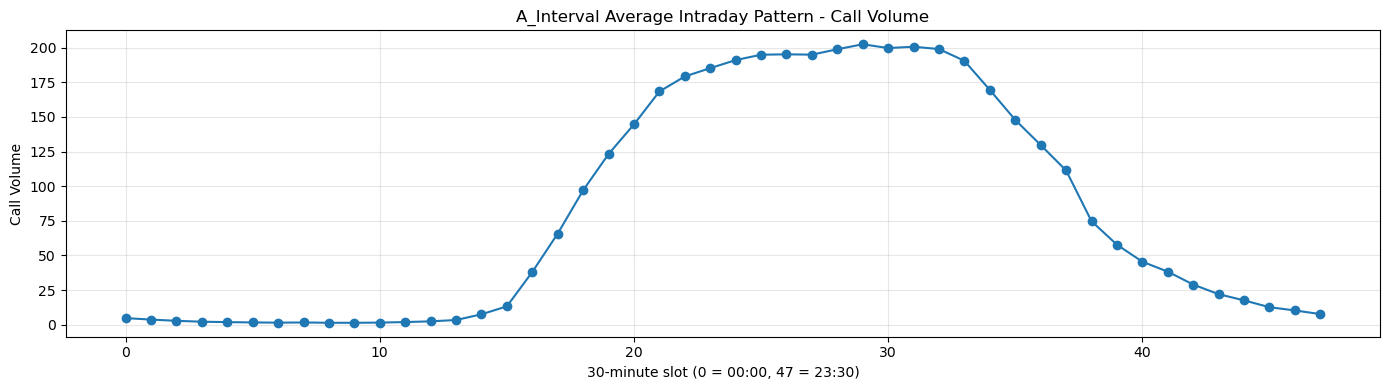

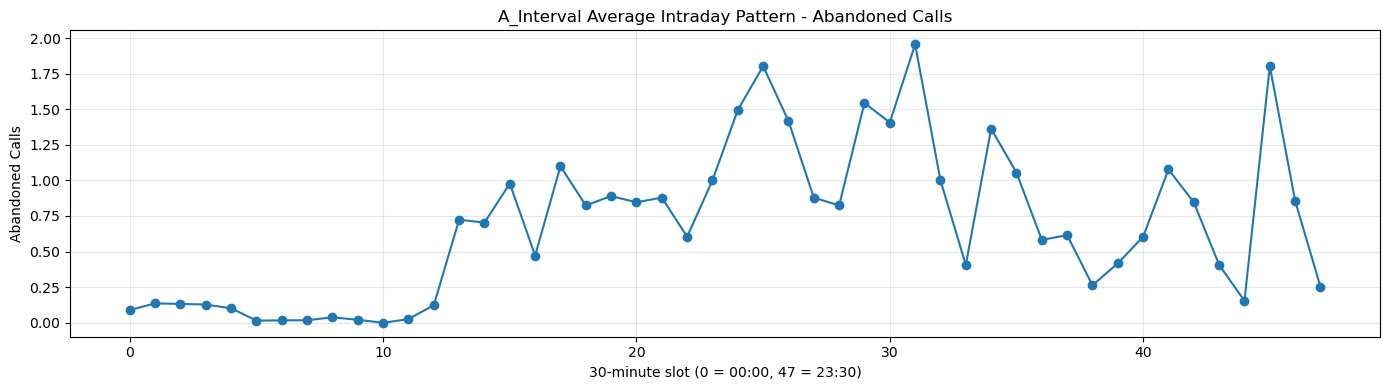

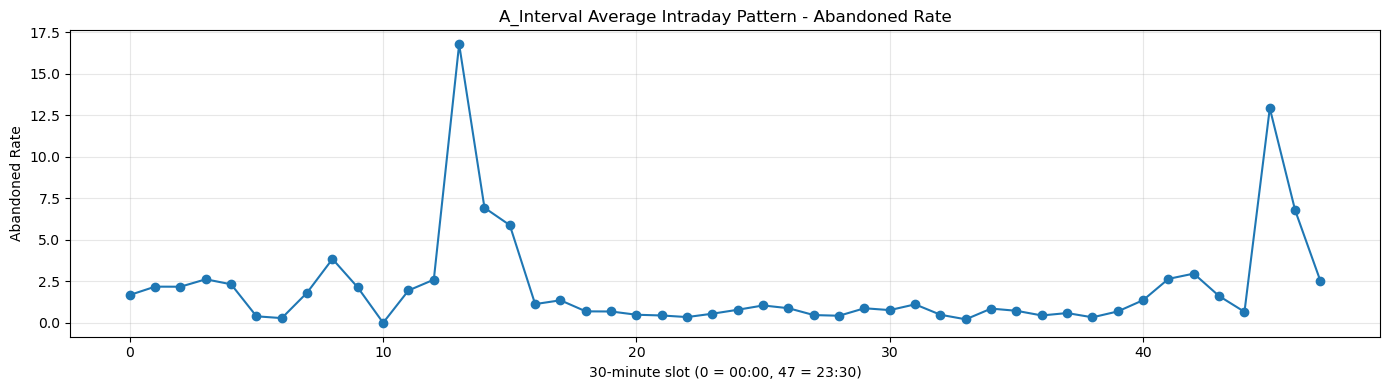

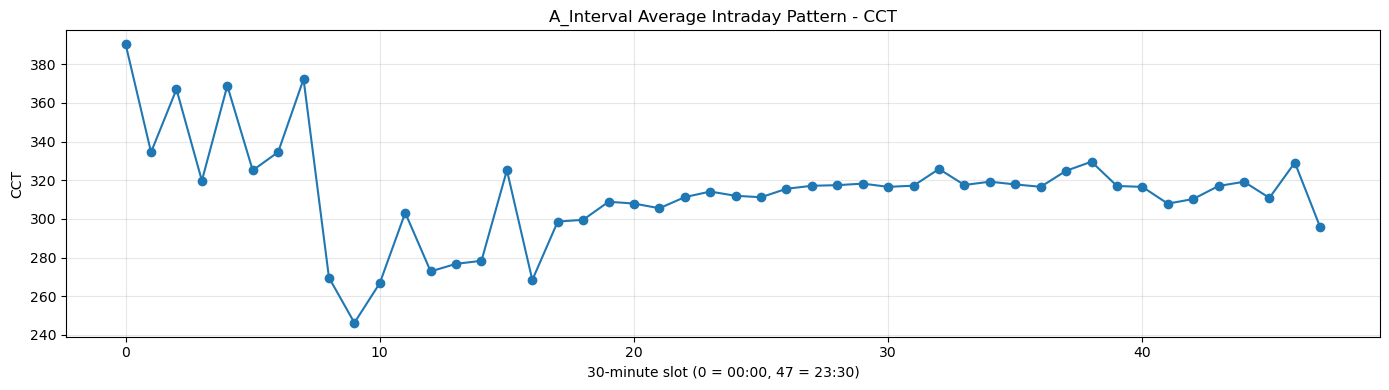

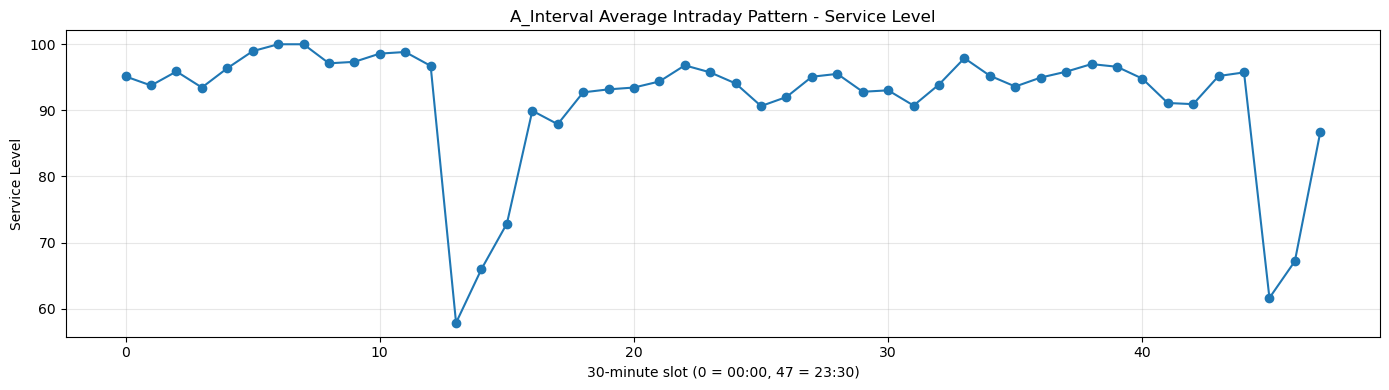

In [12]:
# Average intraday pattern 

intraday_avg = (
    a_int_model.groupby("slot")[["Call Volume", "Abandoned Calls", "Abandoned Rate", "CCT", "Service Level"]]
               .mean()
)

for col in ["Call Volume", "Abandoned Calls", "Abandoned Rate", "CCT", "Service Level"]:
    plt.figure(figsize=(14, 4))
    plt.plot(intraday_avg.index, intraday_avg[col], marker="o")
    plt.title(f"A_Interval Average Intraday Pattern - {col}")
    plt.xlabel("30-minute slot (0 = 00:00, 47 = 23:30)")
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

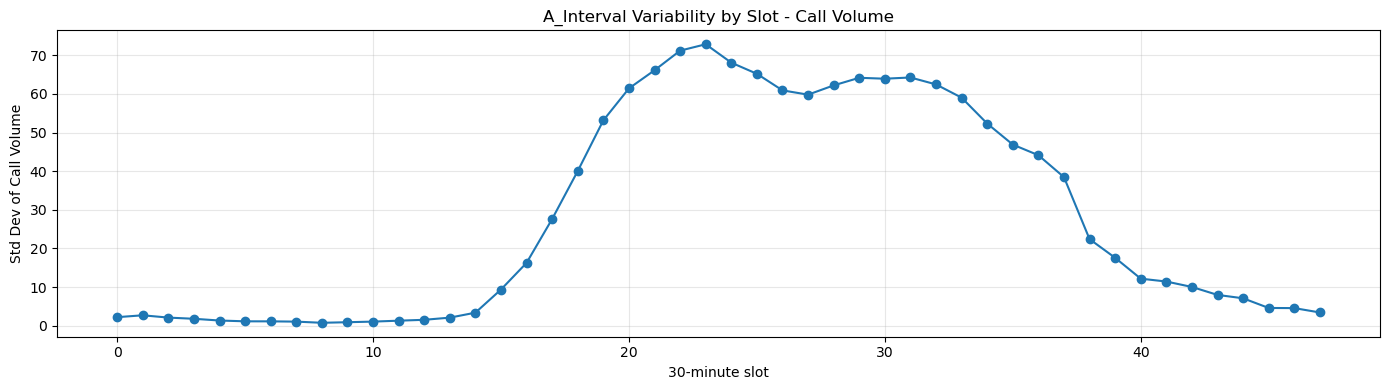

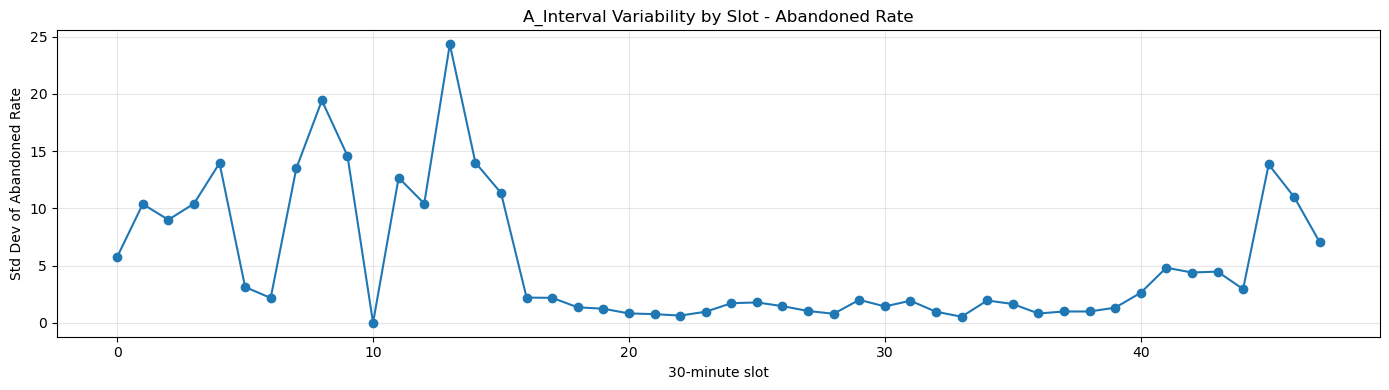

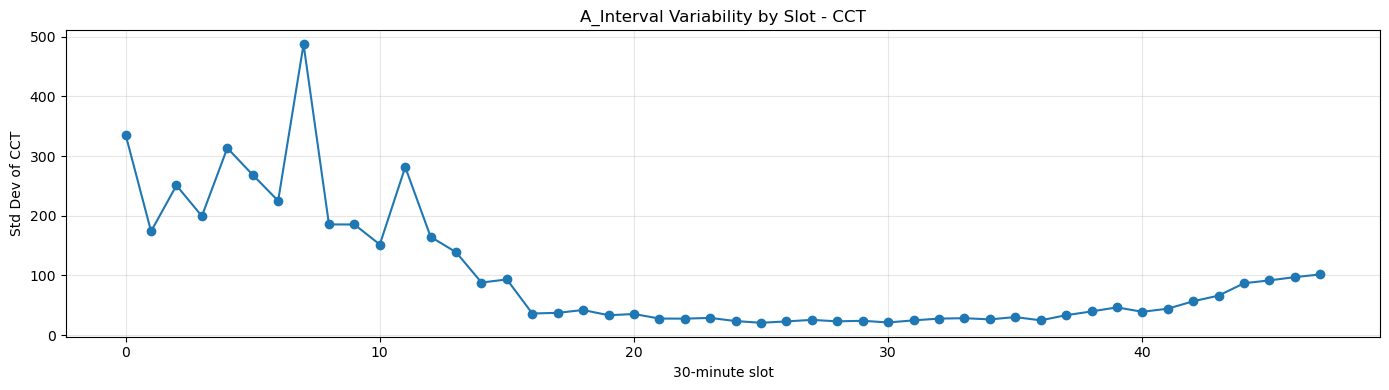

In [13]:
# Variability by plot

intraday_std = (
    a_int_model.groupby("slot")[["Call Volume", "Abandoned Rate", "CCT"]]
               .std()
)

for col in ["Call Volume", "Abandoned Rate", "CCT"]:
    plt.figure(figsize=(14, 4))
    plt.plot(intraday_std.index, intraday_std[col], marker="o")
    plt.title(f"A_Interval Variability by Slot - {col}")
    plt.xlabel("30-minute slot")
    plt.ylabel(f"Std Dev of {col}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

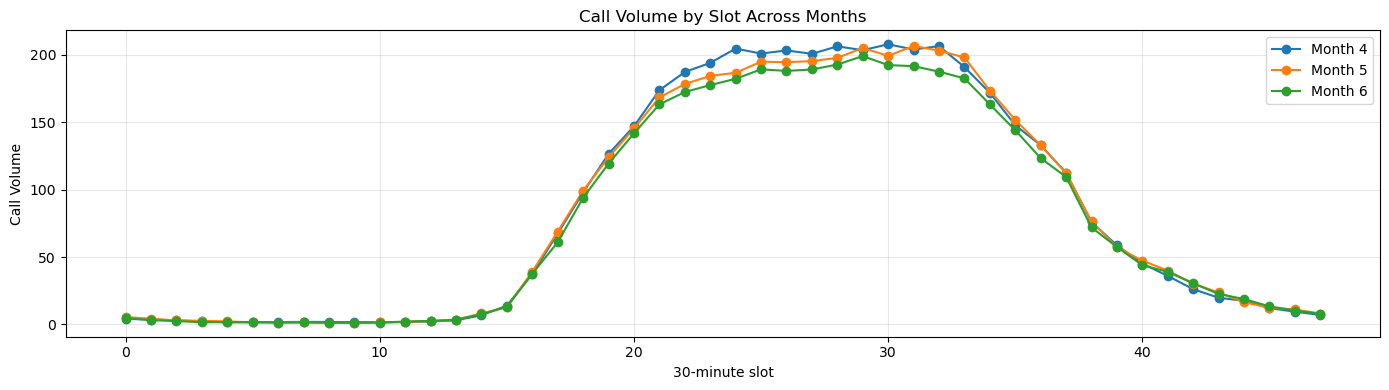

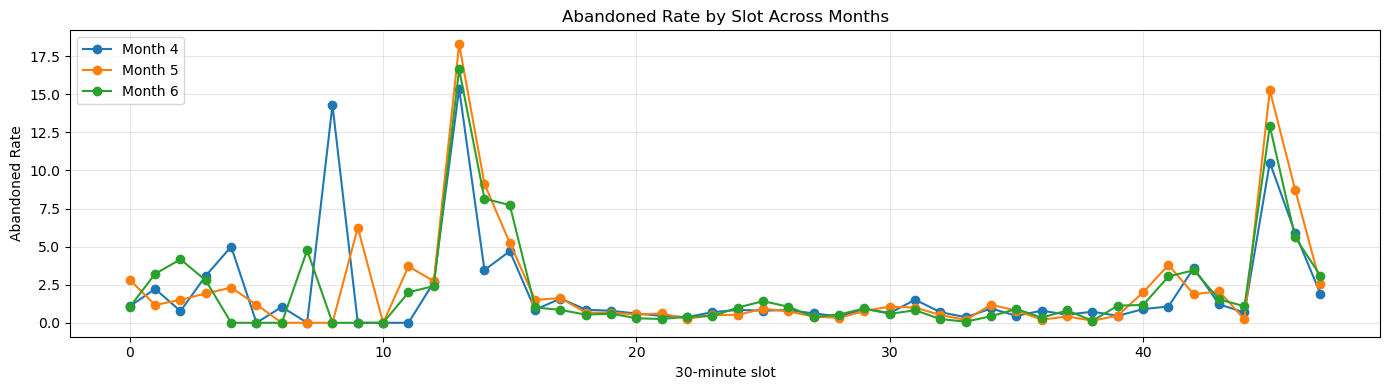

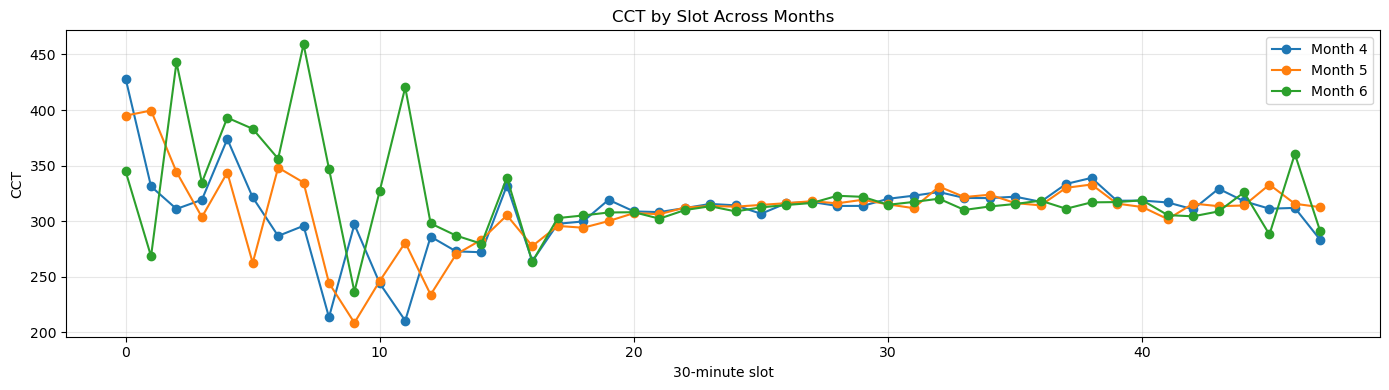

In [15]:
# Monthly Intraday curves

for metric in ["Call Volume", "Abandoned Rate", "CCT"]:
    plt.figure(figsize=(14, 4))
    for m in sorted(a_int_model["Month_num"].dropna().unique()):
        temp = a_int_model[a_int_model["Month_num"] == m]
        curve = temp.groupby("slot")[metric].mean()
        plt.plot(curve.index, curve.values, marker="o", label=f"Month {int(m)}")
    plt.title(f"{metric} by Slot Across Months")
    plt.xlabel("30-minute slot")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [16]:
# Daily roll-up from interval data

tmp = a_int_model.copy()

tmp["Answered Calls"] = (tmp["Call Volume"] - tmp["Abandoned Calls"]).clip(lower=0)
tmp["CCT_x_Answered"] = tmp["CCT"] * tmp["Answered Calls"]

a_interval_daily_rollup = (
    tmp.groupby(["Month_num", "Day"], as_index=False)
       .agg({
           "Call Volume": "sum",
           "Abandoned Calls": "sum",
           "Answered Calls": "sum",
           "CCT_x_Answered": "sum",
           "slot": "nunique"
       })
)

a_interval_daily_rollup["Abandoned Rate_rebuilt"] = np.where(
    a_interval_daily_rollup["Call Volume"] > 0,
    a_interval_daily_rollup["Abandoned Calls"] / a_interval_daily_rollup["Call Volume"] * 100,
    0
)

a_interval_daily_rollup["CCT_weighted"] = np.where(
    a_interval_daily_rollup["Answered Calls"] > 0,
    a_interval_daily_rollup["CCT_x_Answered"] / a_interval_daily_rollup["Answered Calls"],
    np.nan
)

a_interval_daily_rollup["day_key"] = (
    a_interval_daily_rollup["Month_num"].astype(int).astype(str).str.zfill(2)
    + "-"
    + a_interval_daily_rollup["Day"].astype(int).astype(str).str.zfill(2)
)

print(a_interval_daily_rollup.head())
print("\nDays not having all 48 intervals after prep:")
print(a_interval_daily_rollup[a_interval_daily_rollup["slot"] < 48][["day_key", "slot"]])


   Month_num  Day  Call Volume  Abandoned Calls  Answered Calls  \
0          4  1.0       5218.0             24.0          5194.0   
1          4  2.0       4920.0             28.0          4892.0   
2          4  3.0       4944.0             18.5          4925.5   
3          4  4.0       4810.0             17.0          4793.0   
4          4  5.0       3365.0             25.0          3340.0   

   CCT_x_Answered  slot  Abandoned Rate_rebuilt  CCT_weighted day_key  
0     1640908.290    46                0.459946    315.923814   04-01  
1     1584201.470    46                0.569106    323.835133   04-02  
2     1535335.065    45                0.374191    311.711515   04-03  
3     1498448.150    45                0.353430    312.632620   04-04  
4      976717.280    46                0.742942    292.430323   04-05  

Days not having all 48 intervals after prep:
   day_key  slot
0    04-01    46
1    04-02    46
2    04-03    45
3    04-04    45
4    04-05    46
..     ...   ...


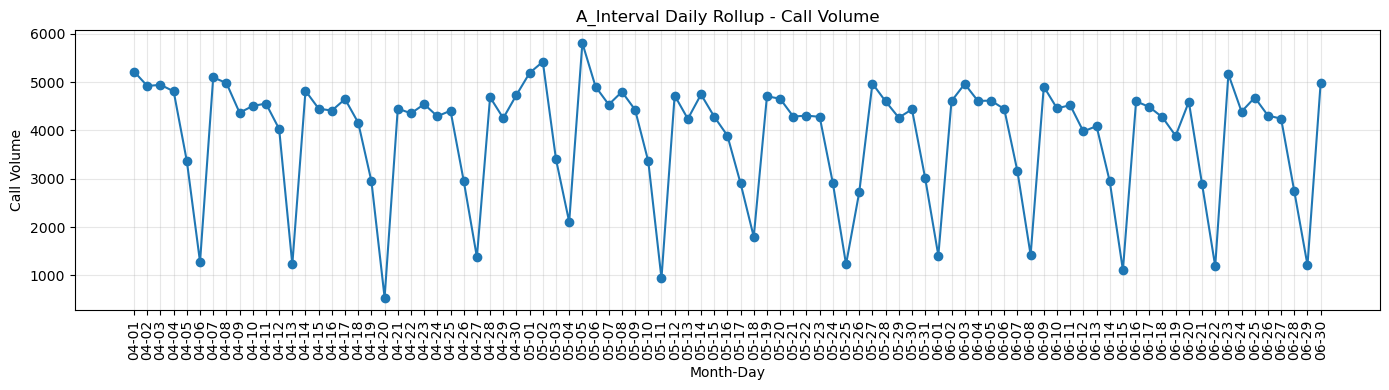

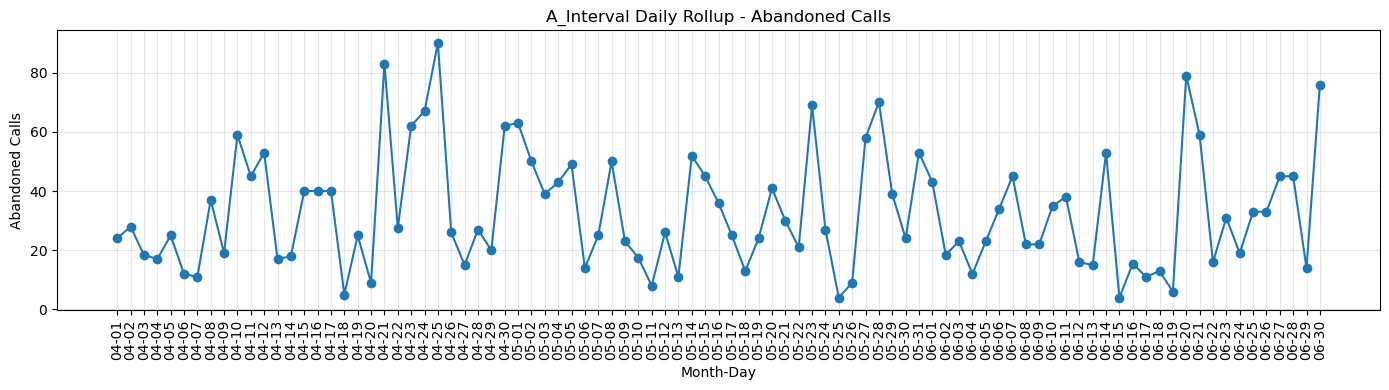

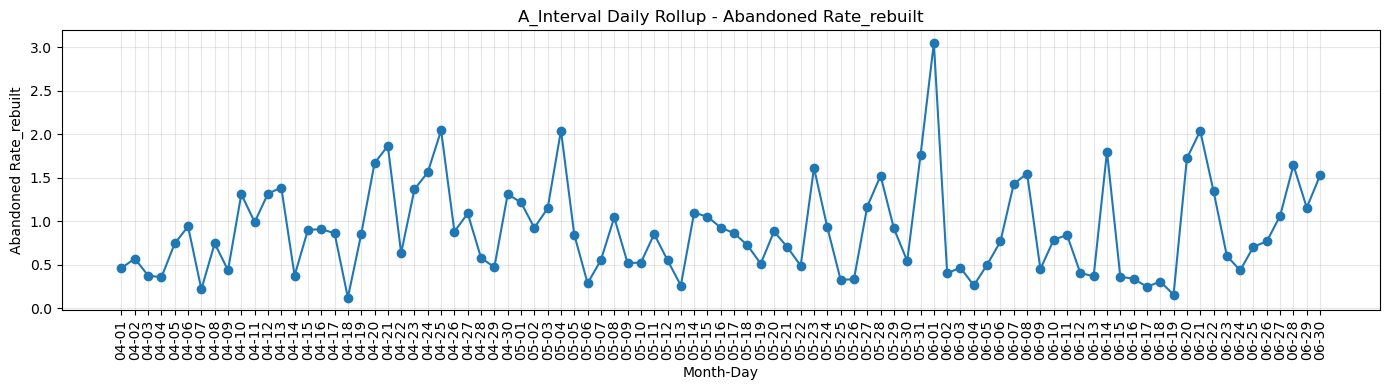

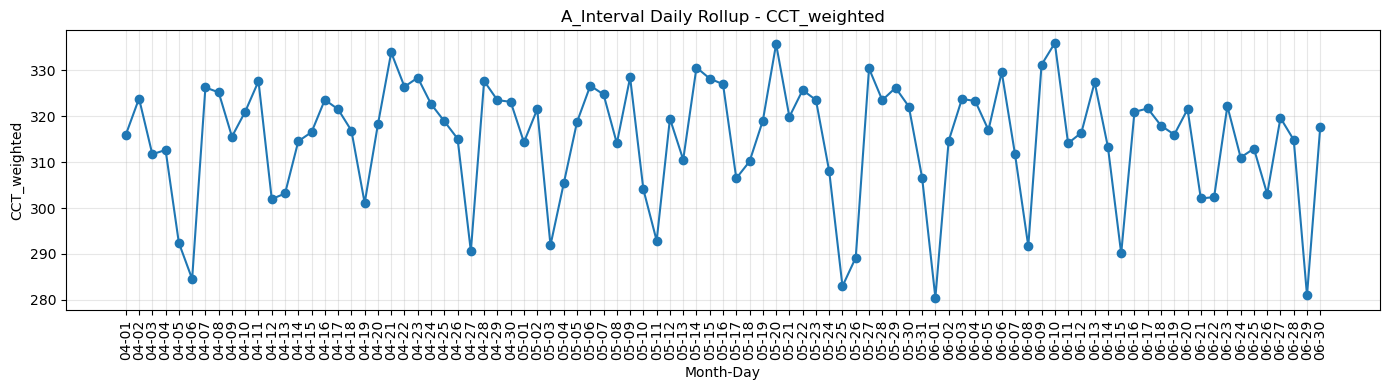

In [17]:
# Plot daily totals

for col in ["Call Volume", "Abandoned Calls", "Abandoned Rate_rebuilt", "CCT_weighted"]:
    plt.figure(figsize=(14, 4))
    plt.plot(a_interval_daily_rollup["day_key"], a_interval_daily_rollup[col], marker="o")
    plt.title(f"A_Interval Daily Rollup - {col}")
    plt.xlabel("Month-Day")
    plt.ylabel(col)
    plt.xticks(rotation=90)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [19]:
# Save the A interval cleaned file

a_int[a_interval_data.columns].to_csv("Dhyey/A_Interval_Cleaned.csv", index=False)

### Model Training

In [33]:
# Daily model training

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 1) LOAD + CLEAN
# =========================
df = pd.read_csv("Dhyey/A_Daily_Clean_MeanImputed.csv")

df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

def clean_numeric(series, percent=False):
    s = series.astype(str).str.strip()
    s = s.replace({
        "": np.nan, "nan": np.nan, "None": np.nan,
        "NA": np.nan, "N/A": np.nan, "-": np.nan
    })
    s = s.str.replace(",", "", regex=False)
    if percent:
        s = s.str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

df["Call Volume"] = clean_numeric(df["Call Volume"])
df["CCT"] = clean_numeric(df["CCT"])
df["Abandon Rate"] = clean_numeric(df["Abandon Rate"], percent=True)

df = df.sort_values("Date").reset_index(drop=True)

# =========================
# 2) BASIC IMPUTATION
# =========================
for col in ["Call Volume", "CCT", "Abandon Rate"]:
    df[col] = df[col].interpolate(method="linear", limit_direction="both")

df["Call Volume"] = df["Call Volume"].clip(lower=0)
df["CCT"] = df["CCT"].clip(lower=0)
df["Abandon Rate"] = df["Abandon Rate"].clip(lower=0)

# =========================
# 3) FEATURE ENGINEERING
# =========================
df["dayofweek"] = df["Date"].dt.dayofweek
df["dayofmonth"] = df["Date"].dt.day
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["dayofyear"] = df["Date"].dt.dayofyear

targets = ["Call Volume", "CCT", "Abandon Rate"]

for target in targets:
    for lag in [1, 7, 14, 28]:
        df[f"{target}_lag_{lag}"] = df[target].shift(lag)

    for win in [7, 14, 28]:
        df[f"{target}_rollmean_{win}"] = df[target].shift(1).rolling(win).mean()
        df[f"{target}_rollstd_{win}"] = df[target].shift(1).rolling(win).std()

    df[f"{target}_ewm_7"] = df[target].shift(1).ewm(span=7, adjust=False).mean()
    df[f"{target}_ewm_14"] = df[target].shift(1).ewm(span=14, adjust=False).mean()

# =========================
# 4) TRAIN / VALID SPLIT
# =========================
model_df = df.dropna().reset_index(drop=True)

feature_cols = [c for c in model_df.columns if c not in ["Date"] + targets]

split_idx = int(len(model_df) * 0.80)
train_df = model_df.iloc[:split_idx].copy()
valid_df = model_df.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
X_valid = valid_df[feature_cols]

# =========================
# 5) METRIC FUNCTION
# =========================
def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    mask = denom != 0
    return 100 * np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask])

def evaluate(y_true, y_pred, target_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    smape_val = smape(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    underforecast_pct = np.mean(y_pred < y_true) * 100

    return {
        "Target": target_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "SMAPE_%": smape_val,
        "Bias_PredMinusActual": bias,
        "Underforecast_%": underforecast_pct
    }

# =========================
# 6) TRAIN XGBOOST MODELS
# =========================
xgb_params = {
    "n_estimators": 500,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1
}

results = []
predictions = valid_df[["Date"]].copy()

for target in targets:
    y_train = train_df[target]
    y_valid = valid_df[target]

    model = XGBRegressor(**xgb_params)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    y_pred = model.predict(X_valid)

    if target in ["Call Volume", "CCT", "Abandon Rate"]:
        y_pred = np.clip(y_pred, 0, None)

    predictions[f"Actual_{target}"] = y_valid.values
    predictions[f"Pred_{target}"] = y_pred

    results.append(evaluate(y_valid.values, y_pred, target))

# =========================
# 7) SHOW RESULTS
# =========================
results_df = pd.DataFrame(results)
print("\nValidation Metrics:")
print(results_df.round(4))

print("\nValidation Predictions Sample:")
print(predictions.head(15))

# =========================
# 8) OPTIONAL: SAVE RESULTS
# =========================
#results_df.to_csv("Dhyey/A_Daily_XGBoost_Metrics_2.csv", index=False)
#predictions.to_csv("Dhyey/A_Daily_XGBoost_Validation_Predictions_2.csv", index=False)

/tmp/ipykernel_14530/4176296043.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")



Validation Metrics:
         Target       MAE      RMSE   MAPE_%  SMAPE_%  Bias_PredMinusActual  \
0   Call Volume  406.3603  651.9330  24.0937  12.3077              108.0983   
1           CCT   12.6770   16.4606   4.1157   4.0447                1.4197   
2  Abandon Rate    0.3760    0.6061  39.2336  31.2639                0.0667   

   Underforecast_%  
0          39.0071  
1          52.4823  
2          35.4610  

Validation Predictions Sample:
          Date  Actual_Call Volume  Pred_Call Volume  Actual_CCT    Pred_CCT  \
562 2025-08-13              3999.0       3899.729736      333.68  307.347656   
563 2025-08-14              4137.0       3877.387207      326.30  316.367676   
564 2025-08-15              3831.0       4067.181152      327.60  318.152649   
565 2025-08-16              3048.0       2452.836670      329.31  315.578705   
566 2025-08-17              1425.0       1107.698120      337.33  313.712646   
567 2025-08-18              4298.0       4788.949219      302.24  

### Clean A-Daily data to mean value for nulls

In [48]:
a_daily_data = pd.read_csv("Dhyey/D-Daily.csv")

In [49]:
print("--------------------- Dataset Info -----------------------")

print(a_daily_data.info()) # information related to column, non null counts, count type and dtypes.

--------------------- Dataset Info -----------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           731 non-null    object 
 1   Call Volume    721 non-null    object 
 2   CCT            699 non-null    float64
 3   Service Level  709 non-null    object 
 4   Abandon Rate   731 non-null    object 
dtypes: float64(1), object(4)
memory usage: 28.7+ KB
None


In [50]:
# Missing Values Count

print("--------------------- Missing Values count -----------------------")
print(a_daily_data.isna().sum().sort_values()) # counting missing values in each column and sorting them in ascending order.

--------------------- Missing Values count -----------------------
Date              0
Abandon Rate      0
Call Volume      10
Service Level    22
CCT              32
dtype: int64


In [51]:
# keep original column order
original_cols = a_daily_data.columns.tolist()

# helper to clean numeric columns
def clean_numeric(series, percent=False):
    s = series.astype(str).str.strip()
    s = s.replace({
        "": np.nan, "nan": np.nan, "None": np.nan,
        "NA": np.nan, "N/A": np.nan, "-": np.nan
    })
    s = s.str.replace(",", "", regex=False)
    if percent:
        s = s.str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

# clean columns
a_daily_clean = a_daily_data.copy()
a_daily_clean.columns = a_daily_clean.columns.str.strip()

# clean numeric fields
a_daily_clean["Call Volume"] = clean_numeric(a_daily_clean["Call Volume"])
a_daily_clean["CCT"] = clean_numeric(a_daily_clean["CCT"])
a_daily_clean["Service Level"] = clean_numeric(a_daily_clean["Service Level"], percent=True)
a_daily_clean["Abandon Rate"] = clean_numeric(a_daily_clean["Abandon Rate"], percent=True)

# fill nulls with column mean
for col in ["Call Volume", "CCT", "Service Level", "Abandon Rate"]:
    a_daily_clean[col] = a_daily_clean[col].fillna(a_daily_clean[col].mean())

# optional checks
print("Missing values before filling:")
print(a_daily_data.isna().sum())

print("\nMissing values after filling:")
print(a_daily_clean.isna().sum())

print("\nMeans used for imputation:")
for col in ["Call Volume", "CCT", "Service Level", "Abandon Rate"]:
    print(f"{col}: {a_daily_clean[col].mean():.4f}")

# save cleaned file with same columns as initial raw file
a_daily_clean[original_cols].to_csv("Dhyey/D_Daily_Clean_MeanImputed.csv", index=False)

Missing values before filling:
Date              0
Call Volume      10
CCT              32
Service Level    22
Abandon Rate      0
dtype: int64

Missing values after filling:
Date             0
Call Volume      0
CCT              0
Service Level    0
Abandon Rate     0
dtype: int64

Means used for imputation:
Call Volume: 10325.4494
CCT: 320.2269
Service Level: 90.5623
Abandon Rate: 1.3146


### Clean A-Interval data to mean values for nulls

In [47]:
a_interval_data = pd.read_csv("Dhyey/D_Interval.csv")


# keep original raw column order
original_cols = a_interval_data.columns.tolist()

a_int = a_interval_data.copy()
a_int.columns = a_int.columns.str.strip()

# standardize possible column naming mismatch
if "Abandon Rate" in a_int.columns and "Abandoned Rate" not in a_int.columns:
    a_int = a_int.rename(columns={"Abandon Rate": "Abandoned Rate"})

def clean_numeric(series, percent=False):
    s = series.astype(str).str.strip()
    s = s.replace({
        "": np.nan, "nan": np.nan, "None": np.nan,
        "NA": np.nan, "N/A": np.nan, "-": np.nan
    })
    s = s.str.replace(",", "", regex=False)
    if percent:
        s = s.str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

month_map = {
    "JAN": 1, "JANUARY": 1,
    "FEB": 2, "FEBRUARY": 2,
    "MAR": 3, "MARCH": 3,
    "APR": 4, "APRIL": 4,
    "MAY": 5,
    "JUN": 6, "JUNE": 6,
    "JUL": 7, "JULY": 7,
    "AUG": 8, "AUGUST": 8,
    "SEP": 9, "SEPT": 9, "SEPTEMBER": 9,
    "OCT": 10, "OCTOBER": 10,
    "NOV": 11, "NOVEMBER": 11,
    "DEC": 12, "DECEMBER": 12
}

# preserve original missing flags for analysis
for col in ["Call Volume", "Abandoned Calls", "Abandoned Rate", "CCT", "Service Level"]:
    if col in a_int.columns:
        a_int[f"{col}_was_missing"] = a_int[col].isna().astype(int)

# normalize key columns
a_int["Month"] = a_int["Month"].astype("string").str.strip().str.upper()
a_int["Month"] = a_int["Month"].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA})

a_int["Day"] = pd.to_numeric(a_int["Day"], errors="coerce")

a_int["Interval"] = a_int["Interval"].astype("string").str.strip()
a_int["Interval"] = a_int["Interval"].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA})

# fill small missing gaps in identifier columns
a_int["Month"] = a_int["Month"].ffill().bfill()
a_int["Day"] = a_int["Day"].ffill().bfill()

a_int["Month_num"] = a_int["Month"].map(month_map)

# parse interval safely without warning
interval_str = a_int["Interval"].astype("string").str.strip()

# first try 24-hour format like 22:30
interval_dt = pd.to_datetime(interval_str, format="%H:%M", errors="coerce")

# then try 12-hour format like 10:30 PM if needed
mask = interval_dt.isna()
if mask.any():
    interval_dt.loc[mask] = pd.to_datetime(interval_str[mask], format="%I:%M %p", errors="coerce")

a_int["slot"] = ((interval_dt.dt.hour * 60 + interval_dt.dt.minute) // 30)
a_int["Hour"] = interval_dt.dt.hour
a_int["Minute"] = interval_dt.dt.minute

# drop rows where interval cannot be placed in the day
a_int = a_int[a_int["slot"].between(0, 47, inclusive="both")].copy()

# convert metrics
a_int["Service Level"] = clean_numeric(a_int["Service Level"], percent=True)
a_int["Call Volume"] = clean_numeric(a_int["Call Volume"])
a_int["Abandoned Calls"] = clean_numeric(a_int["Abandoned Calls"])
a_int["Abandoned Rate"] = clean_numeric(a_int["Abandoned Rate"], percent=True)
a_int["CCT"] = clean_numeric(a_int["CCT"])

# enforce valid ranges
for col in ["Call Volume", "Abandoned Calls", "CCT"]:
    a_int.loc[a_int[col] < 0, col] = np.nan

for col in ["Service Level", "Abandoned Rate"]:
    a_int.loc[(a_int[col] < 0) | (a_int[col] > 100), col] = np.nan

a_int.loc[a_int["Abandoned Calls"] > a_int["Call Volume"], "Abandoned Calls"] = np.nan
a_int.loc[a_int["Abandoned Calls"] > a_int["Call Volume"], "Abandoned Rate"] = np.nan

# logical reconstruction before mean imputation
mask_rate = (
    a_int["Abandoned Rate"].isna() &
    a_int["Abandoned Calls"].notna() &
    a_int["Call Volume"].gt(0)
)
a_int.loc[mask_rate, "Abandoned Rate"] = (
    a_int.loc[mask_rate, "Abandoned Calls"] / a_int.loc[mask_rate, "Call Volume"] * 100
)

mask_calls = (
    a_int["Abandoned Calls"].isna() &
    a_int["Abandoned Rate"].notna() &
    a_int["Call Volume"].notna()
)
a_int.loc[mask_calls, "Abandoned Calls"] = np.round(
    a_int.loc[mask_calls, "Abandoned Rate"] / 100 * a_int.loc[mask_calls, "Call Volume"]
)

# fill remaining nulls in numeric columns with column mean
for col in ["Call Volume", "Abandoned Calls", "Abandoned Rate", "CCT", "Service Level"]:
    a_int[col] = a_int[col].fillna(a_int[col].mean())

# final bounds after mean fill
a_int["Call Volume"] = a_int["Call Volume"].clip(lower=0)
a_int["Abandoned Calls"] = a_int["Abandoned Calls"].clip(lower=0)
a_int["CCT"] = a_int["CCT"].clip(lower=0)
a_int["Service Level"] = a_int["Service Level"].clip(lower=0, upper=100)
a_int["Abandoned Rate"] = a_int["Abandoned Rate"].clip(lower=0, upper=100)

# keep logical consistency
a_int["Abandoned Calls"] = np.minimum(a_int["Abandoned Calls"], a_int["Call Volume"])

a_int = a_int.sort_values(["Month_num", "Day", "slot"]).reset_index(drop=True)

print("Shape after prep:", a_int.shape)
print("\nMissing % after prep:")
print((a_int[["Month", "Day", "Interval", "Call Volume", "Abandoned Calls", "Abandoned Rate", "CCT", "Service Level"]]
       .isna().mean() * 100).round(2))

print("\nMeans used for imputation:")
for col in ["Call Volume", "Abandoned Calls", "Abandoned Rate", "CCT", "Service Level"]:
    print(f"{col}: {a_int[col].mean():.4f}")

# save final cleaned file with same original columns/order
save_cols = [c for c in original_cols if c in a_int.columns]
a_int[save_cols].to_csv("Dhyey/D_Interval_Clean_MeanImputed.csv", index=False)

Shape after prep: (4358, 17)

Missing % after prep:
Month              0.0
Day                0.0
Interval           0.0
Call Volume        0.0
Abandoned Calls    0.0
Abandoned Rate     0.0
CCT                0.0
Service Level      0.0
dtype: float64

Means used for imputation:
Call Volume: 195.5760
Abandoned Calls: 2.7411
Abandoned Rate: 1.4733
CCT: 313.0130
Service Level: 92.2295


### Final Predicted Value

In [57]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

# =========================================================
# CONFIG
# =========================================================
TEMPLATE_PATH = "Dhyey/template_forecast_v00.csv"
OUTPUT_PATH = "Dhyey/forecast_v09.csv"

portfolio_files = {
    "A": {
       "daily": "Dhyey/A_Daily_Clean_MeanImputed.csv",
       "interval": "Dhyey/A_Interval_Clean_MeanImputed.csv"
    }
    #"B": {"daily": "Dhyey/B_Daily_Clean_MeanImputed.csv", "interval": "Dhyey/B_Interval_Clean_MeanImputed.csv"},
    # "C": {"daily": "C_Daily_Clean_MeanImputed.csv", "interval": "C_Interval_Clean_MeanImputed.csv"},
    # "D": {"daily": "D_Daily_Clean_MeanImputed.csv", "interval": "D_Interval_Clean_MeanImputed.csv"},
}

TARGETS = ["Call Volume", "CCT", "Abandon Rate"]

XGB_PARAMS = {
    "n_estimators": 500,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1
}

# =========================================================
# HELPERS
# =========================================================
def standardize_rate_column(df):
    df = df.copy()
    df.columns = df.columns.str.strip()

    # unify both possible names to one internal name
    if "Abandoned Rate" in df.columns and "Abandon Rate" not in df.columns:
        df = df.rename(columns={"Abandoned Rate": "Abandon Rate"})
    return df

def clean_numeric(series, percent=False):
    s = series.astype(str).str.strip()
    s = s.replace({
        "": np.nan, "nan": np.nan, "None": np.nan,
        "NA": np.nan, "N/A": np.nan, "-": np.nan
    })
    s = s.str.replace(",", "", regex=False)
    if percent:
        s = s.str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

def parse_date_safe(series):
    try:
        return pd.to_datetime(series, format="mixed", errors="coerce")
    except Exception:
        return pd.to_datetime(series, errors="coerce")

def build_daily_features(df):
    df = df.sort_values("Date").reset_index(drop=True).copy()

    df["dayofweek"] = df["Date"].dt.dayofweek
    df["dayofmonth"] = df["Date"].dt.day
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["dayofyear"] = df["Date"].dt.dayofyear

    for target in TARGETS:
        for lag in [1, 7, 14, 28]:
            df[f"{target}_lag_{lag}"] = df[target].shift(lag)

        for win in [7, 14, 28]:
            df[f"{target}_rollmean_{win}"] = df[target].shift(1).rolling(win).mean()
            df[f"{target}_rollstd_{win}"] = df[target].shift(1).rolling(win).std()

        df[f"{target}_ewm_7"] = df[target].shift(1).ewm(span=7, adjust=False).mean()
        df[f"{target}_ewm_14"] = df[target].shift(1).ewm(span=14, adjust=False).mean()

    return df

def infer_forecast_year(last_hist_date, template_month_num):
    return last_hist_date.year + (1 if template_month_num < last_hist_date.month else 0)

def train_daily_models(daily_path):
    df = pd.read_csv(daily_path)
    df = standardize_rate_column(df)

    df["Date"] = parse_date_safe(df["Date"])

    df["Call Volume"] = clean_numeric(df["Call Volume"])
    df["CCT"] = clean_numeric(df["CCT"])
    df["Abandon Rate"] = clean_numeric(df["Abandon Rate"], percent=True)

    df = df.sort_values("Date").reset_index(drop=True)

    for col in TARGETS:
        df[col] = df[col].fillna(df[col].mean())
        df[col] = df[col].clip(lower=0)

    feat_df = build_daily_features(df)
    train_df = feat_df.dropna().reset_index(drop=True)

    feature_cols = [c for c in train_df.columns if c not in ["Date"] + TARGETS]

    models = {}
    for target in TARGETS:
        model = XGBRegressor(**XGB_PARAMS)
        model.fit(train_df[feature_cols], train_df[target])
        models[target] = model

    return df, models, feature_cols

def recursive_daily_forecast(hist_df, models, feature_cols, future_dates):
    work_df = hist_df.copy()

    future_stub = pd.DataFrame({"Date": future_dates})
    for col in TARGETS:
        future_stub[col] = np.nan

    work_df = pd.concat([work_df, future_stub], ignore_index=True)

    for current_date in future_dates:
        feat_df = build_daily_features(work_df)
        row = feat_df.loc[feat_df["Date"] == current_date, feature_cols]

        preds = {}
        for target in TARGETS:
            pred = float(models[target].predict(row)[0])
            pred = max(0.0, pred)
            preds[target] = pred

        for target in TARGETS:
            work_df.loc[work_df["Date"] == current_date, target] = preds[target]

    out = work_df[work_df["Date"].isin(future_dates)].copy().reset_index(drop=True)
    return out

def build_interval_profiles(interval_path, daily_hist_df):
    int_df = pd.read_csv(interval_path)
    int_df = standardize_rate_column(int_df)

    int_df["Month"] = int_df["Month"].astype(str).str.strip()
    int_df["Day"] = pd.to_numeric(int_df["Day"], errors="coerce")

    int_df["Call Volume"] = clean_numeric(int_df["Call Volume"])
    int_df["Abandoned Calls"] = clean_numeric(int_df["Abandoned Calls"])
    int_df["Abandon Rate"] = clean_numeric(int_df["Abandon Rate"], percent=True)
    int_df["CCT"] = clean_numeric(int_df["CCT"])

    month_map = {
        "JAN": 1, "JANUARY": 1,
        "FEB": 2, "FEBRUARY": 2,
        "MAR": 3, "MARCH": 3,
        "APR": 4, "APRIL": 4,
        "MAY": 5,
        "JUN": 6, "JUNE": 6,
        "JUL": 7, "JULY": 7,
        "AUG": 8, "AUGUST": 8,
        "SEP": 9, "SEPT": 9, "SEPTEMBER": 9,
        "OCT": 10, "OCTOBER": 10,
        "NOV": 11, "NOVEMBER": 11,
        "DEC": 12, "DECEMBER": 12
    }

    int_df["Month_num"] = int_df["Month"].astype(str).str.upper().map(month_map)

    interval_dt = pd.to_datetime(int_df["Interval"], format="%H:%M", errors="coerce")
    mask = interval_dt.isna()
    if mask.any():
        interval_dt.loc[mask] = pd.to_datetime(
            int_df.loc[mask, "Interval"],
            format="%I:%M %p",
            errors="coerce"
        )

    int_df["slot"] = ((interval_dt.dt.hour * 60 + interval_dt.dt.minute) // 30)

    base_year = int(daily_hist_df["Date"].max().year)
    int_df["Date"] = pd.to_datetime(
        dict(year=base_year, month=int_df["Month_num"], day=int_df["Day"]),
        errors="coerce"
    )

    int_df = int_df.dropna(subset=["Date", "slot"]).copy()
    int_df["slot"] = int_df["slot"].astype(int)
    int_df["DayOfWeek"] = int_df["Date"].dt.dayofweek

    int_df["Call Volume"] = int_df["Call Volume"].clip(lower=0)
    int_df["Abandoned Calls"] = int_df["Abandoned Calls"].clip(lower=0)
    int_df["CCT"] = int_df["CCT"].clip(lower=0)
    int_df["Abandon Rate"] = int_df["Abandon Rate"].clip(lower=0, upper=100)

    tmp = int_df.copy()
    tmp["Abandoned Calls"] = tmp["Abandoned Calls"].fillna(0)
    tmp["Answered Calls"] = (tmp["Call Volume"].fillna(0) - tmp["Abandoned Calls"]).clip(lower=0)
    tmp["CCT_x_Answered"] = tmp["CCT"] * tmp["Answered Calls"]

    daily_roll = (
        tmp.groupby("Date", as_index=False)
           .agg({
               "Call Volume": "sum",
               "Abandoned Calls": "sum",
               "Answered Calls": "sum",
               "CCT_x_Answered": "sum"
           })
    )

    daily_roll["daily_abd"] = np.where(
        daily_roll["Call Volume"] > 0,
        daily_roll["Abandoned Calls"] / daily_roll["Call Volume"] * 100,
        0
    )
    daily_roll["daily_cct"] = np.where(
        daily_roll["Answered Calls"] > 0,
        daily_roll["CCT_x_Answered"] / daily_roll["Answered Calls"],
        np.nan
    )

    int_df = int_df.merge(
        daily_roll[["Date", "Call Volume", "daily_abd", "daily_cct"]].rename(
            columns={"Call Volume": "daily_cv"}
        ),
        on="Date",
        how="left"
    )

    int_df["cv_share"] = np.where(
        int_df["daily_cv"] > 0,
        int_df["Call Volume"] / int_df["daily_cv"],
        np.nan
    )

    cv_share_profile = (
        int_df.groupby(["DayOfWeek", "slot"], as_index=False)["cv_share"]
              .median()
    )
    cv_share_profile["cv_share"] = cv_share_profile["cv_share"].fillna(0)
    cv_share_profile["sum_share"] = cv_share_profile.groupby("DayOfWeek")["cv_share"].transform("sum")
    cv_share_profile["cv_share"] = np.where(
        cv_share_profile["sum_share"] > 0,
        cv_share_profile["cv_share"] / cv_share_profile["sum_share"],
        0
    )
    cv_share_profile = cv_share_profile.drop(columns="sum_share")

    global_cv_share = (
        int_df.groupby("slot", as_index=False)["cv_share"]
              .median()
              .rename(columns={"cv_share": "global_cv_share"})
    )
    global_cv_share["global_cv_share"] = global_cv_share["global_cv_share"].fillna(0)
    gsum = global_cv_share["global_cv_share"].sum()
    if gsum > 0:
        global_cv_share["global_cv_share"] = global_cv_share["global_cv_share"] / gsum

    int_df["cct_factor"] = np.where(
        (int_df["daily_cct"] > 0) & int_df["CCT"].notna(),
        int_df["CCT"] / int_df["daily_cct"],
        np.nan
    )

    cct_factor_profile = (
        int_df.groupby(["DayOfWeek", "slot"], as_index=False)["cct_factor"]
              .median()
    )

    cct_factor_profile = cct_factor_profile.merge(
        cv_share_profile, on=["DayOfWeek", "slot"], how="left"
    )
    cct_factor_profile["cv_share"] = cct_factor_profile["cv_share"].fillna(0)

    norm_cct = cct_factor_profile.groupby("DayOfWeek").apply(
        lambda x: np.nansum(x["cct_factor"] * x["cv_share"])
    ).reset_index(name="norm_cct")

    cct_factor_profile = cct_factor_profile.merge(norm_cct, on="DayOfWeek", how="left")
    cct_factor_profile["cct_factor"] = np.where(
        cct_factor_profile["norm_cct"] > 0,
        cct_factor_profile["cct_factor"] / cct_factor_profile["norm_cct"],
        cct_factor_profile["cct_factor"]
    )
    cct_factor_profile = cct_factor_profile[["DayOfWeek", "slot", "cct_factor"]]

    global_cct_factor = (
        int_df.groupby("slot", as_index=False)["cct_factor"]
              .median()
              .rename(columns={"cct_factor": "global_cct_factor"})
    )
    global_cct_factor = global_cct_factor.merge(global_cv_share, on="slot", how="left")
    norm_gcct = np.nansum(global_cct_factor["global_cct_factor"] * global_cct_factor["global_cv_share"])
    if norm_gcct > 0:
        global_cct_factor["global_cct_factor"] = global_cct_factor["global_cct_factor"] / norm_gcct
    global_cct_factor = global_cct_factor[["slot", "global_cct_factor"]]

    int_df["abd_factor"] = np.where(
        (int_df["daily_abd"] > 0) & int_df["Abandon Rate"].notna(),
        int_df["Abandon Rate"] / int_df["daily_abd"],
        np.nan
    )

    abd_factor_profile = (
        int_df.groupby(["DayOfWeek", "slot"], as_index=False)["abd_factor"]
              .median()
    )

    abd_factor_profile = abd_factor_profile.merge(
        cv_share_profile, on=["DayOfWeek", "slot"], how="left"
    )
    abd_factor_profile["cv_share"] = abd_factor_profile["cv_share"].fillna(0)

    norm_abd = abd_factor_profile.groupby("DayOfWeek").apply(
        lambda x: np.nansum(x["abd_factor"] * x["cv_share"])
    ).reset_index(name="norm_abd")

    abd_factor_profile = abd_factor_profile.merge(norm_abd, on="DayOfWeek", how="left")
    abd_factor_profile["abd_factor"] = np.where(
        abd_factor_profile["norm_abd"] > 0,
        abd_factor_profile["abd_factor"] / abd_factor_profile["norm_abd"],
        abd_factor_profile["abd_factor"]
    )
    abd_factor_profile = abd_factor_profile[["DayOfWeek", "slot", "abd_factor"]]

    global_abd_factor = (
        int_df.groupby("slot", as_index=False)["abd_factor"]
              .median()
              .rename(columns={"abd_factor": "global_abd_factor"})
    )
    global_abd_factor = global_abd_factor.merge(global_cv_share, on="slot", how="left")
    norm_gabd = np.nansum(global_abd_factor["global_abd_factor"] * global_abd_factor["global_cv_share"])
    if norm_gabd > 0:
        global_abd_factor["global_abd_factor"] = global_abd_factor["global_abd_factor"] / norm_gabd
    global_abd_factor = global_abd_factor[["slot", "global_abd_factor"]]

    return {
        "cv_share_profile": cv_share_profile,
        "global_cv_share": global_cv_share,
        "cct_factor_profile": cct_factor_profile,
        "global_cct_factor": global_cct_factor,
        "abd_factor_profile": abd_factor_profile,
        "global_abd_factor": global_abd_factor
    }

def fill_portfolio_forecast(template_df, portfolio_label, daily_path, interval_path):
    # train daily models
    hist_df, models, feature_cols = train_daily_models(daily_path)

    # build forecast dates from template
    temp = template_df[["Month", "Day"]].drop_duplicates().copy()
    temp["Month_num"] = pd.to_datetime(temp["Month"], format="%B").dt.month
    forecast_month_num = int(temp["Month_num"].iloc[0])

    forecast_year = infer_forecast_year(hist_df["Date"].max(), forecast_month_num)
    temp["Date"] = pd.to_datetime(
        dict(year=forecast_year, month=temp["Month_num"], day=temp["Day"]),
        errors="coerce"
    )
    future_dates = sorted(temp["Date"].dropna().unique())

    future_daily = recursive_daily_forecast(hist_df, models, feature_cols, future_dates)
    future_daily["Day"] = future_daily["Date"].dt.day
    future_daily["Month"] = future_daily["Date"].dt.month_name()
    future_daily["DayOfWeek"] = future_daily["Date"].dt.dayofweek

    # interval profiles
    profiles = build_interval_profiles(interval_path, hist_df)

    cv_share_map = {
        (int(r["DayOfWeek"]), int(r["slot"])): float(r["cv_share"])
        for _, r in profiles["cv_share_profile"].iterrows()
    }
    global_cv_share_map = {
        int(r["slot"]): float(r["global_cv_share"])
        for _, r in profiles["global_cv_share"].iterrows()
    }

    cct_factor_map = {
        (int(r["DayOfWeek"]), int(r["slot"])): float(r["cct_factor"])
        for _, r in profiles["cct_factor_profile"].dropna().iterrows()
    }
    global_cct_factor_map = {
        int(r["slot"]): float(r["global_cct_factor"])
        for _, r in profiles["global_cct_factor"].dropna().iterrows()
    }

    abd_factor_map = {
        (int(r["DayOfWeek"]), int(r["slot"])): float(r["abd_factor"])
        for _, r in profiles["abd_factor_profile"].dropna().iterrows()
    }
    global_abd_factor_map = {
        int(r["slot"]): float(r["global_abd_factor"])
        for _, r in profiles["global_abd_factor"].dropna().iterrows()
    }

    # template prep
    out = template_df.copy()
    interval_dt = pd.to_datetime(out["Interval"], format="%H:%M", errors="coerce")
    if interval_dt.isna().any():
        interval_dt = pd.to_datetime(out["Interval"], errors="coerce")
    out["slot"] = ((interval_dt.dt.hour * 60 + interval_dt.dt.minute) // 30).astype(int)

    out["Month_num"] = pd.to_datetime(out["Month"], format="%B").dt.month
    out["Date"] = pd.to_datetime(
        dict(year=forecast_year, month=out["Month_num"], day=out["Day"]),
        errors="coerce"
    )
    out["DayOfWeek"] = out["Date"].dt.dayofweek

    out = out.merge(
        future_daily[["Date", "Call Volume", "CCT", "Abandon Rate"]].rename(columns={
            "Call Volume": f"daily_cv_pred_{portfolio_label}",
            "CCT": f"daily_cct_pred_{portfolio_label}",
            "Abandon Rate": f"daily_abd_pred_{portfolio_label}"
        }),
        on="Date",
        how="left"
    )

    def get_share(dow, slot):
        return cv_share_map.get((int(dow), int(slot)), global_cv_share_map.get(int(slot), 1/48))

    def get_cct_factor(dow, slot):
        return cct_factor_map.get((int(dow), int(slot)), global_cct_factor_map.get(int(slot), 1.0))

    def get_abd_factor(dow, slot):
        return abd_factor_map.get((int(dow), int(slot)), global_abd_factor_map.get(int(slot), 1.0))

    out[f"_cv_share_{portfolio_label}"] = out.apply(lambda r: get_share(r["DayOfWeek"], r["slot"]), axis=1)
    out[f"_cct_factor_{portfolio_label}"] = out.apply(lambda r: get_cct_factor(r["DayOfWeek"], r["slot"]), axis=1)
    out[f"_abd_factor_{portfolio_label}"] = out.apply(lambda r: get_abd_factor(r["DayOfWeek"], r["slot"]), axis=1)

    # interval predictions
    out[f"Calls_Offered_{portfolio_label}"] = (
        out[f"daily_cv_pred_{portfolio_label}"] * out[f"_cv_share_{portfolio_label}"]
    ).clip(lower=0)

    out[f"CCT_{portfolio_label}"] = (
        out[f"daily_cct_pred_{portfolio_label}"] * out[f"_cct_factor_{portfolio_label}"]
    ).clip(lower=0)

    out[f"Abandoned_Rate_{portfolio_label}"] = (
        out[f"daily_abd_pred_{portfolio_label}"] * out[f"_abd_factor_{portfolio_label}"]
    ).clip(lower=0, upper=100)

    out[f"Abandoned_Calls_{portfolio_label}"] = (
        out[f"Calls_Offered_{portfolio_label}"] * out[f"Abandoned_Rate_{portfolio_label}"] / 100.0
    ).clip(lower=0)

    # optional rounding
    out[f"Calls_Offered_{portfolio_label}"] = out[f"Calls_Offered_{portfolio_label}"].round(4)
    out[f"Abandoned_Calls_{portfolio_label}"] = out[f"Abandoned_Calls_{portfolio_label}"].round(4)
    out[f"Abandoned_Rate_{portfolio_label}"] = out[f"Abandoned_Rate_{portfolio_label}"].round(4)
    out[f"CCT_{portfolio_label}"] = out[f"CCT_{portfolio_label}"].round(4)

    # drop helper cols
    drop_cols = [c for c in out.columns if c.startswith("daily_") or c.startswith("_")]
    out = out.drop(columns=drop_cols + ["slot", "Month_num", "Date", "DayOfWeek"], errors="ignore")

    return out

# =========================================================
# RUN
# =========================================================
template_df = pd.read_csv(TEMPLATE_PATH)

filled_df = template_df.copy()
for p, paths in portfolio_files.items():
    filled_df = fill_portfolio_forecast(
        template_df=filled_df,
        portfolio_label=p,
        daily_path=paths["daily"],
        interval_path=paths["interval"]
    )

filled_df.to_csv(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)
print(filled_df.head())
print("\nFilled columns:")
print([c for c in filled_df.columns if filled_df[c].notna().any()])

Saved: Dhyey/forecast_v09.csv
    Month  Day Interval  Calls_Offered_A  Abandoned_Calls_A  Abandoned_Rate_A  \
0  August    1     0:00              NaN                NaN               NaN   
1  August    1     0:30              NaN                NaN               NaN   
2  August    1     1:00              NaN                NaN               NaN   
3  August    1     1:30              NaN                NaN               NaN   
4  August    1     2:00              NaN                NaN               NaN   

   CCT_A  Calls_Offered_B  Abandoned_Calls_B  Abandoned_Rate_B     CCT_B  \
0    NaN          33.6543             0.1688            0.5015  290.4806   
1    NaN          25.0687             0.0000            0.0000  337.0743   
2    NaN           8.3911             0.0000            0.0000  382.4267   
3    NaN           5.1901             0.0000            0.0000  266.7864   
4    NaN           5.0090             0.0000            0.0000  301.6682   

   Calls_Offered_C  Abando

/tmp/ipykernel_14530/3454256354.py:279: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  norm_cct = cct_factor_profile.groupby("DayOfWeek").apply(
/tmp/ipykernel_14530/3454256354.py:318: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  norm_abd = abd_factor_profile.groupby("DayOfWeek").apply(


In [60]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

# =========================================================
# CONFIG
# =========================================================
TEMPLATE_PATH = "Dhyey/template_forecast_v00.csv"
OUTPUT_PATH = "Dhyey/forecast_v10.csv"

portfolio_files = {
    "A": {
        "daily": "Dhyey/A_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/A_Interval_Clean_MeanImputed.csv"
    },
    "B": {
        "daily": "Dhyey/B_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/B_Interval_Clean_MeanImputed.csv"
    },
    "C": {
        "daily": "Dhyey/C_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/C_Interval_Clean_MeanImputed.csv"
    },
    "D": {
        "daily": "Dhyey/D_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/D_Interval_Clean_MeanImputed.csv"
    },
}

TARGETS = ["Call Volume", "CCT", "Abandon Rate"]

XGB_PARAMS = {
    "n_estimators": 500,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1
}

# =========================================================
# HELPERS
# =========================================================
def standardize_rate_column(df):
    df = df.copy()
    df.columns = df.columns.str.strip()

    # unify both possible names to one internal name
    if "Abandoned Rate" in df.columns and "Abandon Rate" not in df.columns:
        df = df.rename(columns={"Abandoned Rate": "Abandon Rate"})
    return df

def clean_numeric(series, percent=False):
    s = series.astype(str).str.strip()
    s = s.replace({
        "": np.nan, "nan": np.nan, "None": np.nan,
        "NA": np.nan, "N/A": np.nan, "-": np.nan
    })
    s = s.str.replace(",", "", regex=False)
    if percent:
        s = s.str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

def parse_date_safe(series):
    try:
        return pd.to_datetime(series, format="mixed", errors="coerce")
    except Exception:
        return pd.to_datetime(series, errors="coerce")

def parse_interval_to_slot(series):
    s = series.astype(str).str.strip()

    dt = pd.to_datetime(s, format="%H:%M", errors="coerce")
    mask = dt.isna()
    if mask.any():
        dt2 = pd.to_datetime(s[mask], format="%I:%M %p", errors="coerce")
        dt.loc[mask] = dt2

    mask = dt.isna()
    if mask.any():
        dt3 = pd.to_datetime(s[mask], errors="coerce")
        dt.loc[mask] = dt3

    slot = ((dt.dt.hour * 60 + dt.dt.minute) // 30)
    return slot

def build_daily_features(df):
    df = df.sort_values("Date").reset_index(drop=True).copy()

    df["dayofweek"] = df["Date"].dt.dayofweek
    df["dayofmonth"] = df["Date"].dt.day
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["dayofyear"] = df["Date"].dt.dayofyear

    for target in TARGETS:
        for lag in [1, 7, 14, 28]:
            df[f"{target}_lag_{lag}"] = df[target].shift(lag)

        for win in [7, 14, 28]:
            df[f"{target}_rollmean_{win}"] = df[target].shift(1).rolling(win).mean()
            df[f"{target}_rollstd_{win}"] = df[target].shift(1).rolling(win).std()

        df[f"{target}_ewm_7"] = df[target].shift(1).ewm(span=7, adjust=False).mean()
        df[f"{target}_ewm_14"] = df[target].shift(1).ewm(span=14, adjust=False).mean()

    return df

def infer_forecast_year(last_hist_date, template_month_num):
    return last_hist_date.year + (1 if template_month_num < last_hist_date.month else 0)

def train_daily_models(daily_path):
    df = pd.read_csv(daily_path)
    df = standardize_rate_column(df)

    df["Date"] = parse_date_safe(df["Date"])
    df["Call Volume"] = clean_numeric(df["Call Volume"])
    df["CCT"] = clean_numeric(df["CCT"])
    df["Abandon Rate"] = clean_numeric(df["Abandon Rate"], percent=True)

    df = df.sort_values("Date").reset_index(drop=True)

    for col in TARGETS:
        df[col] = df[col].fillna(df[col].mean())
        df[col] = df[col].clip(lower=0)

    feat_df = build_daily_features(df)
    train_df = feat_df.dropna().reset_index(drop=True)

    feature_cols = [c for c in train_df.columns if c not in ["Date"] + TARGETS]

    models = {}
    for target in TARGETS:
        model = XGBRegressor(**XGB_PARAMS)
        model.fit(train_df[feature_cols], train_df[target])
        models[target] = model

    return df, models, feature_cols

def recursive_daily_forecast(hist_df, models, feature_cols, future_dates):
    work_df = hist_df.copy()

    future_stub = pd.DataFrame({"Date": future_dates})
    for col in TARGETS:
        future_stub[col] = np.nan

    work_df = pd.concat([work_df, future_stub], ignore_index=True)

    for current_date in future_dates:
        feat_df = build_daily_features(work_df)
        row = feat_df.loc[feat_df["Date"] == current_date, feature_cols]

        preds = {}
        for target in TARGETS:
            pred = float(models[target].predict(row)[0])
            preds[target] = max(0.0, pred)

        for target in TARGETS:
            work_df.loc[work_df["Date"] == current_date, target] = preds[target]

    out = work_df[work_df["Date"].isin(future_dates)].copy().reset_index(drop=True)
    return out

def build_interval_profiles(interval_path, daily_hist_df):
    int_df = pd.read_csv(interval_path)
    int_df = standardize_rate_column(int_df)

    int_df["Month"] = int_df["Month"].astype(str).str.strip()
    int_df["Day"] = pd.to_numeric(int_df["Day"], errors="coerce")
    int_df["Call Volume"] = clean_numeric(int_df["Call Volume"])
    int_df["Abandoned Calls"] = clean_numeric(int_df["Abandoned Calls"])
    int_df["Abandon Rate"] = clean_numeric(int_df["Abandon Rate"], percent=True)
    int_df["CCT"] = clean_numeric(int_df["CCT"])

    month_map = {
        "JAN": 1, "JANUARY": 1,
        "FEB": 2, "FEBRUARY": 2,
        "MAR": 3, "MARCH": 3,
        "APR": 4, "APRIL": 4,
        "MAY": 5,
        "JUN": 6, "JUNE": 6,
        "JUL": 7, "JULY": 7,
        "AUG": 8, "AUGUST": 8,
        "SEP": 9, "SEPT": 9, "SEPTEMBER": 9,
        "OCT": 10, "OCTOBER": 10,
        "NOV": 11, "NOVEMBER": 11,
        "DEC": 12, "DECEMBER": 12
    }

    int_df["Month_num"] = int_df["Month"].astype(str).str.upper().map(month_map)
    int_df["slot"] = parse_interval_to_slot(int_df["Interval"])

    base_year = int(daily_hist_df["Date"].max().year)
    int_df["Date"] = pd.to_datetime(
        dict(year=base_year, month=int_df["Month_num"], day=int_df["Day"]),
        errors="coerce"
    )

    int_df = int_df.dropna(subset=["Date", "slot"]).copy()
    int_df["slot"] = int_df["slot"].astype(int)
    int_df["DayOfWeek"] = int_df["Date"].dt.dayofweek

    int_df["Call Volume"] = int_df["Call Volume"].fillna(int_df["Call Volume"].mean()).clip(lower=0)
    int_df["Abandoned Calls"] = int_df["Abandoned Calls"].fillna(int_df["Abandoned Calls"].mean()).clip(lower=0)
    int_df["CCT"] = int_df["CCT"].fillna(int_df["CCT"].mean()).clip(lower=0)
    int_df["Abandon Rate"] = int_df["Abandon Rate"].fillna(int_df["Abandon Rate"].mean()).clip(lower=0, upper=100)

    tmp = int_df.copy()
    tmp["Answered Calls"] = (tmp["Call Volume"] - tmp["Abandoned Calls"]).clip(lower=0)
    tmp["CCT_x_Answered"] = tmp["CCT"] * tmp["Answered Calls"]

    daily_roll = (
        tmp.groupby("Date", as_index=False)
           .agg({
               "Call Volume": "sum",
               "Abandoned Calls": "sum",
               "Answered Calls": "sum",
               "CCT_x_Answered": "sum"
           })
    )

    daily_roll["daily_abd"] = np.where(
        daily_roll["Call Volume"] > 0,
        daily_roll["Abandoned Calls"] / daily_roll["Call Volume"] * 100,
        0
    )
    daily_roll["daily_cct"] = np.where(
        daily_roll["Answered Calls"] > 0,
        daily_roll["CCT_x_Answered"] / daily_roll["Answered Calls"],
        np.nan
    )

    int_df = int_df.merge(
        daily_roll[["Date", "Call Volume", "daily_abd", "daily_cct"]].rename(
            columns={"Call Volume": "daily_cv"}
        ),
        on="Date",
        how="left"
    )

    # CV share
    int_df["cv_share"] = np.where(
        int_df["daily_cv"] > 0,
        int_df["Call Volume"] / int_df["daily_cv"],
        np.nan
    )

    cv_share_profile = (
        int_df.groupby(["DayOfWeek", "slot"], as_index=False)["cv_share"]
              .median()
    )
    cv_share_profile["cv_share"] = cv_share_profile["cv_share"].fillna(0)
    cv_share_profile["sum_share"] = cv_share_profile.groupby("DayOfWeek")["cv_share"].transform("sum")
    cv_share_profile["cv_share"] = np.where(
        cv_share_profile["sum_share"] > 0,
        cv_share_profile["cv_share"] / cv_share_profile["sum_share"],
        0
    )
    cv_share_profile = cv_share_profile.drop(columns="sum_share")

    global_cv_share = (
        int_df.groupby("slot", as_index=False)["cv_share"]
              .median()
              .rename(columns={"cv_share": "global_cv_share"})
    )
    global_cv_share["global_cv_share"] = global_cv_share["global_cv_share"].fillna(0)
    gsum = global_cv_share["global_cv_share"].sum()
    if gsum > 0:
        global_cv_share["global_cv_share"] = global_cv_share["global_cv_share"] / gsum

    # CCT factor
    int_df["cct_factor"] = np.where(
        (int_df["daily_cct"] > 0) & int_df["CCT"].notna(),
        int_df["CCT"] / int_df["daily_cct"],
        np.nan
    )

    cct_factor_profile = (
        int_df.groupby(["DayOfWeek", "slot"], as_index=False)["cct_factor"]
              .median()
    )
    cct_factor_profile = cct_factor_profile.merge(
        cv_share_profile, on=["DayOfWeek", "slot"], how="left"
    )
    cct_factor_profile["cv_share"] = cct_factor_profile["cv_share"].fillna(0)

    norm_cct = cct_factor_profile.groupby("DayOfWeek").apply(
        lambda x: np.nansum(x["cct_factor"] * x["cv_share"])
    ).reset_index(name="norm_cct")

    cct_factor_profile = cct_factor_profile.merge(norm_cct, on="DayOfWeek", how="left")
    cct_factor_profile["cct_factor"] = np.where(
        cct_factor_profile["norm_cct"] > 0,
        cct_factor_profile["cct_factor"] / cct_factor_profile["norm_cct"],
        cct_factor_profile["cct_factor"]
    )
    cct_factor_profile = cct_factor_profile[["DayOfWeek", "slot", "cct_factor"]]

    global_cct_factor = (
        int_df.groupby("slot", as_index=False)["cct_factor"]
              .median()
              .rename(columns={"cct_factor": "global_cct_factor"})
    )
    global_cct_factor = global_cct_factor.merge(global_cv_share, on="slot", how="left")
    norm_gcct = np.nansum(global_cct_factor["global_cct_factor"] * global_cct_factor["global_cv_share"])
    if norm_gcct > 0:
        global_cct_factor["global_cct_factor"] = global_cct_factor["global_cct_factor"] / norm_gcct
    global_cct_factor = global_cct_factor[["slot", "global_cct_factor"]]

    # ABD factor
    int_df["abd_factor"] = np.where(
        (int_df["daily_abd"] > 0) & int_df["Abandon Rate"].notna(),
        int_df["Abandon Rate"] / int_df["daily_abd"],
        np.nan
    )

    abd_factor_profile = (
        int_df.groupby(["DayOfWeek", "slot"], as_index=False)["abd_factor"]
              .median()
    )
    abd_factor_profile = abd_factor_profile.merge(
        cv_share_profile, on=["DayOfWeek", "slot"], how="left"
    )
    abd_factor_profile["cv_share"] = abd_factor_profile["cv_share"].fillna(0)

    norm_abd = abd_factor_profile.groupby("DayOfWeek").apply(
        lambda x: np.nansum(x["abd_factor"] * x["cv_share"])
    ).reset_index(name="norm_abd")

    abd_factor_profile = abd_factor_profile.merge(norm_abd, on="DayOfWeek", how="left")
    abd_factor_profile["abd_factor"] = np.where(
        abd_factor_profile["norm_abd"] > 0,
        abd_factor_profile["abd_factor"] / abd_factor_profile["norm_abd"],
        abd_factor_profile["abd_factor"]
    )
    abd_factor_profile = abd_factor_profile[["DayOfWeek", "slot", "abd_factor"]]

    global_abd_factor = (
        int_df.groupby("slot", as_index=False)["abd_factor"]
              .median()
              .rename(columns={"abd_factor": "global_abd_factor"})
    )
    global_abd_factor = global_abd_factor.merge(global_cv_share, on="slot", how="left")
    norm_gabd = np.nansum(global_abd_factor["global_abd_factor"] * global_abd_factor["global_cv_share"])
    if norm_gabd > 0:
        global_abd_factor["global_abd_factor"] = global_abd_factor["global_abd_factor"] / norm_gabd
    global_abd_factor = global_abd_factor[["slot", "global_abd_factor"]]

    return {
        "cv_share_profile": cv_share_profile,
        "global_cv_share": global_cv_share,
        "cct_factor_profile": cct_factor_profile,
        "global_cct_factor": global_cct_factor,
        "abd_factor_profile": abd_factor_profile,
        "global_abd_factor": global_abd_factor
    }

def add_portfolio_predictions(template_df, portfolio_label, daily_path, interval_path):
    out = template_df.copy()

    hist_df, models, feature_cols = train_daily_models(daily_path)

    temp = out[["Month", "Day"]].drop_duplicates().copy()
    temp["Month_num"] = pd.to_datetime(temp["Month"], format="%B").dt.month
    forecast_month_num = int(temp["Month_num"].iloc[0])

    forecast_year = infer_forecast_year(hist_df["Date"].max(), forecast_month_num)
    temp["Date"] = pd.to_datetime(
        dict(year=forecast_year, month=temp["Month_num"], day=temp["Day"]),
        errors="coerce"
    )
    future_dates = sorted(temp["Date"].dropna().unique())

    future_daily = recursive_daily_forecast(hist_df, models, feature_cols, future_dates)
    future_daily["DayOfWeek"] = future_daily["Date"].dt.dayofweek

    profiles = build_interval_profiles(interval_path, hist_df)

    cv_share_map = {
        (int(r["DayOfWeek"]), int(r["slot"])): float(r["cv_share"])
        for _, r in profiles["cv_share_profile"].iterrows()
    }
    global_cv_share_map = {
        int(r["slot"]): float(r["global_cv_share"])
        for _, r in profiles["global_cv_share"].iterrows()
    }

    cct_factor_map = {
        (int(r["DayOfWeek"]), int(r["slot"])): float(r["cct_factor"])
        for _, r in profiles["cct_factor_profile"].dropna().iterrows()
    }
    global_cct_factor_map = {
        int(r["slot"]): float(r["global_cct_factor"])
        for _, r in profiles["global_cct_factor"].dropna().iterrows()
    }

    abd_factor_map = {
        (int(r["DayOfWeek"]), int(r["slot"])): float(r["abd_factor"])
        for _, r in profiles["abd_factor_profile"].dropna().iterrows()
    }
    global_abd_factor_map = {
        int(r["slot"]): float(r["global_abd_factor"])
        for _, r in profiles["global_abd_factor"].dropna().iterrows()
    }

    out["slot"] = parse_interval_to_slot(out["Interval"]).astype("Int64")
    out["Month_num"] = pd.to_datetime(out["Month"], format="%B").dt.month
    out["Date"] = pd.to_datetime(
        dict(year=forecast_year, month=out["Month_num"], day=out["Day"]),
        errors="coerce"
    )
    out["DayOfWeek"] = out["Date"].dt.dayofweek

    daily_pred_map = future_daily.set_index("Date")[["Call Volume", "CCT", "Abandon Rate"]].to_dict("index")

    def get_share(dow, slot):
        if pd.isna(dow) or pd.isna(slot):
            return 1 / 48
        return cv_share_map.get((int(dow), int(slot)), global_cv_share_map.get(int(slot), 1 / 48))

    def get_cct_factor(dow, slot):
        if pd.isna(dow) or pd.isna(slot):
            return 1.0
        return cct_factor_map.get((int(dow), int(slot)), global_cct_factor_map.get(int(slot), 1.0))

    def get_abd_factor(dow, slot):
        if pd.isna(dow) or pd.isna(slot):
            return 1.0
        return abd_factor_map.get((int(dow), int(slot)), global_abd_factor_map.get(int(slot), 1.0))

    calls_col = f"Calls_Offered_{portfolio_label}"
    abd_calls_col = f"Abandoned_Calls_{portfolio_label}"
    abd_rate_col = f"Abandoned_Rate_{portfolio_label}"
    cct_col = f"CCT_{portfolio_label}"

    out[calls_col] = np.nan
    out[abd_calls_col] = np.nan
    out[abd_rate_col] = np.nan
    out[cct_col] = np.nan

    for idx, row in out.iterrows():
        dt = row["Date"]
        dow = row["DayOfWeek"]
        slot = row["slot"]

        if pd.isna(dt) or dt not in daily_pred_map:
            continue

        daily_cv = max(0.0, daily_pred_map[dt]["Call Volume"])
        daily_cct = max(0.0, daily_pred_map[dt]["CCT"])
        daily_abd = max(0.0, daily_pred_map[dt]["Abandon Rate"])

        share = get_share(dow, slot)
        cct_factor = get_cct_factor(dow, slot)
        abd_factor = get_abd_factor(dow, slot)

        calls_offered = max(0.0, daily_cv * share)
        cct_pred = max(0.0, daily_cct * cct_factor)
        abd_rate_pred = min(100.0, max(0.0, daily_abd * abd_factor))
        abd_calls_pred = max(0.0, calls_offered * abd_rate_pred / 100.0)

        out.at[idx, calls_col] = round(calls_offered, 4)
        out.at[idx, abd_calls_col] = round(abd_calls_pred, 4)
        out.at[idx, abd_rate_col] = round(abd_rate_pred, 4)
        out.at[idx, cct_col] = round(cct_pred, 4)

    out = out.drop(columns=["slot", "Month_num", "Date", "DayOfWeek"], errors="ignore")
    return out

# =========================================================
# RUN
# =========================================================
template_df = pd.read_csv(TEMPLATE_PATH)
template_df.columns = template_df.columns.str.strip()

filled_df = template_df.copy()

for p, paths in portfolio_files.items():
    filled_df = add_portfolio_predictions(
        template_df=filled_df,
        portfolio_label=p,
        daily_path=paths["daily"],
        interval_path=paths["interval"]
    )

filled_df.to_csv(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)
print(filled_df.head())
print("\nNon-null counts:")
print(filled_df.notna().sum())

/tmp/ipykernel_14530/1906627464.py:291: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  norm_cct = cct_factor_profile.groupby("DayOfWeek").apply(
/tmp/ipykernel_14530/1906627464.py:330: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  norm_abd = abd_factor_profile.groupby("DayOfWeek").apply(
/tmp/ipykernel_14530/1906627464.py:291: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is dep

Saved: Dhyey/forecast_v10.csv
    Month  Day Interval  Calls_Offered_A  Abandoned_Calls_A  Abandoned_Rate_A  \
0  August    1     0:00           6.6312                0.0               0.0   
1  August    1     0:30           5.4436                0.0               0.0   
2  August    1     1:00           3.5153                0.0               0.0   
3  August    1     1:30           2.1723                0.0               0.0   
4  August    1     2:00           1.0895                0.0               0.0   

      CCT_A  Calls_Offered_B  Abandoned_Calls_B  Abandoned_Rate_B     CCT_B  \
0  328.6838          33.6543             0.1688            0.5015  290.4806   
1  415.0029          25.0687             0.0000            0.0000  337.0743   
2  285.5342           8.3911             0.0000            0.0000  382.4267   
3  157.4991           5.1901             0.0000            0.0000  266.7864   
4  330.8903           5.0090             0.0000            0.0000  301.6682   

   Calls

In [62]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

# =========================================================
# CONFIG
# =========================================================
TEMPLATE_PATH = "Dhyey/template_forecast_v00.csv"
OUTPUT_PATH = "Dhyey/forecast_v33.csv"

portfolio_files = {
    "A": {
        "daily": "Dhyey/A_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/A_Interval_Clean_MeanImputed.csv"
    },
    "B": {
        "daily": "Dhyey/B_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/B_Interval_Clean_MeanImputed.csv"
    },
    "C": {
        "daily": "Dhyey/C_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/C_Interval_Clean_MeanImputed.csv"
    },
    "D": {
        "daily": "Dhyey/D_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/D_Interval_Clean_MeanImputed.csv"
    },
}

TARGETS = ["Call Volume", "CCT", "Abandon Rate"]

TARGET_CONFIG = {
    "Call Volume": {
        "use_log": True,
        "blend": {"xgb": 0.70, "lag7": 0.20, "roll7": 0.10},
        "clip_upper": None,
        "params": {
            "n_estimators": 800,
            "max_depth": 5,
            "learning_rate": 0.03,
            "subsample": 0.90,
            "colsample_bytree": 0.90,
            "reg_alpha": 0.05,
            "reg_lambda": 1.5,
            "min_child_weight": 3,
            "objective": "reg:squarederror",
            "random_state": 42,
            "n_jobs": -1
        }
    },
    "CCT": {
        "use_log": True,
        "blend": {"xgb": 0.80, "lag7": 0.15, "roll7": 0.05},
        "clip_upper": None,
        "params": {
            "n_estimators": 700,
            "max_depth": 4,
            "learning_rate": 0.035,
            "subsample": 0.90,
            "colsample_bytree": 0.90,
            "reg_alpha": 0.02,
            "reg_lambda": 1.2,
            "min_child_weight": 2,
            "objective": "reg:squarederror",
            "random_state": 42,
            "n_jobs": -1
        }
    },
    "Abandon Rate": {
        "use_log": False,
        "blend": {"xgb": 0.60, "lag7": 0.25, "roll7": 0.15},
        "clip_upper": 100.0,
        "params": {
            "n_estimators": 600,
            "max_depth": 3,
            "learning_rate": 0.04,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "reg_alpha": 0.10,
            "reg_lambda": 2.0,
            "min_child_weight": 4,
            "objective": "reg:squarederror",
            "random_state": 42,
            "n_jobs": -1
        }
    }
}

# =========================================================
# HELPERS
# =========================================================
def standardize_rate_column(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    if "Abandoned Rate" in df.columns and "Abandon Rate" not in df.columns:
        df = df.rename(columns={"Abandoned Rate": "Abandon Rate"})
    return df

def clean_numeric(series, percent=False):
    s = series.astype(str).str.strip()
    s = s.replace({
        "": np.nan, "nan": np.nan, "None": np.nan,
        "NA": np.nan, "N/A": np.nan, "-": np.nan
    })
    s = s.str.replace(",", "", regex=False)
    if percent:
        s = s.str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

def parse_date_safe(series):
    try:
        return pd.to_datetime(series, format="mixed", errors="coerce")
    except Exception:
        return pd.to_datetime(series, errors="coerce")

def parse_interval_to_slot(series):
    s = series.astype(str).str.strip()

    dt = pd.to_datetime(s, format="%H:%M", errors="coerce")
    mask = dt.isna()
    if mask.any():
        dt2 = pd.to_datetime(s[mask], format="%I:%M %p", errors="coerce")
        dt.loc[mask] = dt2

    mask = dt.isna()
    if mask.any():
        dt3 = pd.to_datetime(s[mask], errors="coerce")
        dt.loc[mask] = dt3

    return ((dt.dt.hour * 60 + dt.dt.minute) // 30)

def normalize_share(df, share_col, group_col):
    df = df.copy()
    denom = df.groupby(group_col)[share_col].transform("sum")
    df[share_col] = np.where(denom > 0, df[share_col] / denom, 1 / 48)
    return df

def prepare_daily(df):
    df = standardize_rate_column(df)
    df["Date"] = parse_date_safe(df["Date"])
    df["Call Volume"] = clean_numeric(df["Call Volume"])
    df["CCT"] = clean_numeric(df["CCT"])
    df["Abandon Rate"] = clean_numeric(df["Abandon Rate"], percent=True)

    df = df.sort_values("Date").reset_index(drop=True)

    # time-aware fill instead of plain mean
    for col in TARGETS:
        df[col] = df[col].interpolate(method="linear", limit_direction="both")
        month_dow_med = df.groupby([df["Date"].dt.month, df["Date"].dt.dayofweek])[col].transform("median")
        dow_med = df.groupby(df["Date"].dt.dayofweek)[col].transform("median")
        df[col] = df[col].fillna(month_dow_med).fillna(dow_med).fillna(df[col].median())
        df[col] = df[col].clip(lower=0)

    df["Abandon Rate"] = df["Abandon Rate"].clip(upper=100)
    return df

def build_daily_features(df):
    df = df.sort_values("Date").reset_index(drop=True).copy()

    df["dayofweek"] = df["Date"].dt.dayofweek
    df["dayofmonth"] = df["Date"].dt.day
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["dayofyear"] = df["Date"].dt.dayofyear

    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7.0)
    df["doy_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)

    for target in TARGETS:
        for lag in [1, 2, 3, 7, 14, 21, 28]:
            df[f"{target}_lag_{lag}"] = df[target].shift(lag)

        for win in [3, 7, 14, 28]:
            shifted = df[target].shift(1)
            df[f"{target}_rollmean_{win}"] = shifted.rolling(win).mean()
            df[f"{target}_rollstd_{win}"] = shifted.rolling(win).std()
            df[f"{target}_rollmin_{win}"] = shifted.rolling(win).min()
            df[f"{target}_rollmax_{win}"] = shifted.rolling(win).max()

        for span in [7, 14, 28]:
            df[f"{target}_ewm_{span}"] = df[target].shift(1).ewm(span=span, adjust=False).mean()

    for target in TARGETS:
        df[f"{target}_dow_median"] = df.groupby("dayofweek")[target].transform("median")
        df[f"{target}_month_median"] = df.groupby("month")[target].transform("median")

    return df

def infer_forecast_year(last_hist_date, template_month_num):
    return last_hist_date.year + (1 if template_month_num < last_hist_date.month else 0)

def train_daily_models(daily_path):
    raw_df = pd.read_csv(daily_path)
    df = prepare_daily(raw_df)

    feat_df = build_daily_features(df)
    model_df = feat_df.dropna().reset_index(drop=True)

    feature_cols = [c for c in model_df.columns if c not in ["Date"] + TARGETS]

    # recent holdout for calibration
    holdout_n = min(28, max(14, len(model_df) // 8))
    split_idx = len(model_df) - holdout_n
    fit_df = model_df.iloc[:split_idx].copy()
    val_df = model_df.iloc[split_idx:].copy()

    models = {}
    calibrators = {}

    for target in TARGETS:
        cfg = TARGET_CONFIG[target]
        model = XGBRegressor(**cfg["params"])

        y_fit = np.log1p(fit_df[target]) if cfg["use_log"] else fit_df[target]
        model.fit(fit_df[feature_cols], y_fit)

        raw_val_pred = model.predict(val_df[feature_cols])
        raw_val_pred = np.expm1(raw_val_pred) if cfg["use_log"] else raw_val_pred
        raw_val_pred = np.clip(raw_val_pred, 0, None)

        if target == "Abandon Rate":
            bias_add = np.nanmedian(val_df[target] - raw_val_pred)
            bias_add = float(np.clip(bias_add, -2.0, 2.0))
            calibrators[target] = {"type": "add", "value": bias_add}
        else:
            ratio = np.nanmedian(val_df[target] / np.maximum(raw_val_pred, 1e-6))
            ratio = float(np.clip(ratio, 0.85, 1.15))
            calibrators[target] = {"type": "mul", "value": ratio}

        final_model = XGBRegressor(**cfg["params"])
        y_full = np.log1p(model_df[target]) if cfg["use_log"] else model_df[target]
        final_model.fit(model_df[feature_cols], y_full)
        models[target] = final_model

    return df, models, feature_cols, calibrators

def apply_daily_postprocess(target, xgb_pred, lag7_val, roll7_val, calibrators):
    cfg = TARGET_CONFIG[target]
    lag7_val = 0.0 if pd.isna(lag7_val) else float(lag7_val)
    roll7_val = 0.0 if pd.isna(roll7_val) else float(roll7_val)

    blended = (
        cfg["blend"]["xgb"] * float(xgb_pred) +
        cfg["blend"]["lag7"] * lag7_val +
        cfg["blend"]["roll7"] * roll7_val
    )

    cal = calibrators[target]
    if cal["type"] == "mul":
        blended *= cal["value"]
    else:
        blended += cal["value"]

    blended = max(0.0, blended)
    if cfg["clip_upper"] is not None:
        blended = min(cfg["clip_upper"], blended)
    return blended

def recursive_daily_forecast(hist_df, models, feature_cols, future_dates, calibrators):
    work_df = hist_df.copy()

    future_stub = pd.DataFrame({"Date": future_dates})
    for col in TARGETS:
        future_stub[col] = np.nan

    work_df = pd.concat([work_df, future_stub], ignore_index=True)

    for current_date in future_dates:
        feat_df = build_daily_features(work_df)
        row = feat_df.loc[feat_df["Date"] == current_date].copy()
        X_row = row[feature_cols]

        preds = {}
        for target in TARGETS:
            cfg = TARGET_CONFIG[target]
            raw_pred = models[target].predict(X_row)[0]
            raw_pred = np.expm1(raw_pred) if cfg["use_log"] else raw_pred
            raw_pred = max(0.0, float(raw_pred))

            lag7_val = row[f"{target}_lag_7"].iloc[0] if f"{target}_lag_7" in row.columns else np.nan
            roll7_val = row[f"{target}_rollmean_7"].iloc[0] if f"{target}_rollmean_7" in row.columns else np.nan

            preds[target] = apply_daily_postprocess(target, raw_pred, lag7_val, roll7_val, calibrators)

        for target in TARGETS:
            work_df.loc[work_df["Date"] == current_date, target] = preds[target]

    return work_df[work_df["Date"].isin(future_dates)].copy().reset_index(drop=True)

def build_interval_profiles(interval_path, daily_hist_df):
    int_df = pd.read_csv(interval_path)
    int_df = standardize_rate_column(int_df)

    int_df["Month"] = int_df["Month"].astype(str).str.strip()
    int_df["Day"] = pd.to_numeric(int_df["Day"], errors="coerce")
    int_df["Call Volume"] = clean_numeric(int_df["Call Volume"])
    int_df["Abandoned Calls"] = clean_numeric(int_df["Abandoned Calls"])
    int_df["Abandon Rate"] = clean_numeric(int_df["Abandon Rate"], percent=True)
    int_df["CCT"] = clean_numeric(int_df["CCT"])

    month_map = {
        "JAN": 1, "JANUARY": 1,
        "FEB": 2, "FEBRUARY": 2,
        "MAR": 3, "MARCH": 3,
        "APR": 4, "APRIL": 4,
        "MAY": 5,
        "JUN": 6, "JUNE": 6,
        "JUL": 7, "JULY": 7,
        "AUG": 8, "AUGUST": 8,
        "SEP": 9, "SEPT": 9, "SEPTEMBER": 9,
        "OCT": 10, "OCTOBER": 10,
        "NOV": 11, "NOVEMBER": 11,
        "DEC": 12, "DECEMBER": 12
    }

    int_df["Month_num"] = int_df["Month"].astype(str).str.upper().map(month_map)
    int_df["slot"] = parse_interval_to_slot(int_df["Interval"])
    base_year = int(daily_hist_df["Date"].max().year)

    int_df["Date"] = pd.to_datetime(
        dict(year=base_year, month=int_df["Month_num"], day=int_df["Day"]),
        errors="coerce"
    )
    int_df = int_df.dropna(subset=["Date", "slot"]).copy()
    int_df["slot"] = int_df["slot"].astype(int)
    int_df["DayOfWeek"] = int_df["Date"].dt.dayofweek

    # slot-aware fill
    for col in ["Call Volume", "Abandoned Calls", "CCT", "Abandon Rate"]:
        dow_slot_med = int_df.groupby(["DayOfWeek", "slot"])[col].transform("median")
        slot_med = int_df.groupby("slot")[col].transform("median")
        int_df[col] = int_df[col].fillna(dow_slot_med).fillna(slot_med).fillna(int_df[col].median())

    int_df["Call Volume"] = int_df["Call Volume"].clip(lower=0)
    int_df["Abandoned Calls"] = np.minimum(int_df["Abandoned Calls"].clip(lower=0), int_df["Call Volume"])
    int_df["CCT"] = int_df["CCT"].clip(lower=0)
    int_df["Abandon Rate"] = int_df["Abandon Rate"].clip(lower=0, upper=100)

    tmp = int_df.copy()
    tmp["Answered Calls"] = (tmp["Call Volume"] - tmp["Abandoned Calls"]).clip(lower=0)
    tmp["CCT_x_Answered"] = tmp["CCT"] * tmp["Answered Calls"]

    daily_roll = (
        tmp.groupby("Date", as_index=False)
           .agg({
               "Call Volume": "sum",
               "Abandoned Calls": "sum",
               "Answered Calls": "sum",
               "CCT_x_Answered": "sum"
           })
    )

    daily_roll["daily_abd"] = np.where(
        daily_roll["Call Volume"] > 0,
        daily_roll["Abandoned Calls"] / daily_roll["Call Volume"] * 100,
        0
    )
    daily_roll["daily_cct"] = np.where(
        daily_roll["Answered Calls"] > 0,
        daily_roll["CCT_x_Answered"] / daily_roll["Answered Calls"],
        np.nan
    )

    int_df = int_df.merge(
        daily_roll[["Date", "Call Volume", "daily_abd", "daily_cct"]].rename(columns={"Call Volume": "daily_cv"}),
        on="Date",
        how="left"
    )

    recent_cutoff = int_df["Date"].max() - pd.Timedelta(days=28)
    recent_df = int_df[int_df["Date"] >= recent_cutoff].copy()

    # CV share
    int_df["cv_share"] = np.where(int_df["daily_cv"] > 0, int_df["Call Volume"] / int_df["daily_cv"], np.nan)
    recent_df["cv_share"] = np.where(recent_df["daily_cv"] > 0, recent_df["Call Volume"] / recent_df["daily_cv"], np.nan)

    full_share = int_df.groupby(["DayOfWeek", "slot"], as_index=False)["cv_share"].median().rename(columns={"cv_share": "full_share"})
    recent_share = recent_df.groupby(["DayOfWeek", "slot"], as_index=False)["cv_share"].median().rename(columns={"cv_share": "recent_share"})
    global_share = int_df.groupby("slot", as_index=False)["cv_share"].median().rename(columns={"cv_share": "global_share"})

    cv_share_profile = full_share.merge(recent_share, on=["DayOfWeek", "slot"], how="outer")
    cv_share_profile = cv_share_profile.merge(global_share, on="slot", how="left")
    cv_share_profile["full_share"] = cv_share_profile["full_share"].fillna(0)
    cv_share_profile["recent_share"] = cv_share_profile["recent_share"].fillna(cv_share_profile["full_share"])
    cv_share_profile["global_share"] = cv_share_profile["global_share"].fillna(1 / 48)
    cv_share_profile["cv_share"] = (
        0.50 * cv_share_profile["recent_share"] +
        0.35 * cv_share_profile["full_share"] +
        0.15 * cv_share_profile["global_share"]
    )
    cv_share_profile = normalize_share(cv_share_profile[["DayOfWeek", "slot", "cv_share"]], "cv_share", "DayOfWeek")

    global_cv_share = int_df.groupby("slot", as_index=False)["cv_share"].median().rename(columns={"cv_share": "global_cv_share"})
    global_cv_share["global_cv_share"] = global_cv_share["global_cv_share"].fillna(1 / 48)
    gsum = global_cv_share["global_cv_share"].sum()
    if gsum > 0:
        global_cv_share["global_cv_share"] /= gsum

    # CCT factor
    int_df["cct_factor"] = np.where((int_df["daily_cct"] > 0) & int_df["CCT"].notna(), int_df["CCT"] / int_df["daily_cct"], np.nan)
    recent_df["cct_factor"] = np.where((recent_df["daily_cct"] > 0) & recent_df["CCT"].notna(), recent_df["CCT"] / recent_df["daily_cct"], np.nan)

    full_cct = int_df.groupby(["DayOfWeek", "slot"], as_index=False)["cct_factor"].median().rename(columns={"cct_factor": "full_cct"})
    recent_cct = recent_df.groupby(["DayOfWeek", "slot"], as_index=False)["cct_factor"].median().rename(columns={"cct_factor": "recent_cct"})
    global_cct = int_df.groupby("slot", as_index=False)["cct_factor"].median().rename(columns={"cct_factor": "global_cct"})

    cct_factor_profile = full_cct.merge(recent_cct, on=["DayOfWeek", "slot"], how="outer")
    cct_factor_profile = cct_factor_profile.merge(global_cct, on="slot", how="left")
    cct_factor_profile = cct_factor_profile.merge(cv_share_profile, on=["DayOfWeek", "slot"], how="left")
    cct_factor_profile["full_cct"] = cct_factor_profile["full_cct"].fillna(1.0)
    cct_factor_profile["recent_cct"] = cct_factor_profile["recent_cct"].fillna(cct_factor_profile["full_cct"])
    cct_factor_profile["global_cct"] = cct_factor_profile["global_cct"].fillna(1.0)
    cct_factor_profile["cct_factor"] = (
        0.50 * cct_factor_profile["recent_cct"] +
        0.35 * cct_factor_profile["full_cct"] +
        0.15 * cct_factor_profile["global_cct"]
    ).clip(0.25, 4.0)

    norm_cct = cct_factor_profile.groupby("DayOfWeek").apply(
        lambda x: np.nansum(x["cct_factor"] * x["cv_share"])
    ).reset_index(name="norm_cct")
    cct_factor_profile = cct_factor_profile.merge(norm_cct, on="DayOfWeek", how="left")
    cct_factor_profile["cct_factor"] = np.where(
        cct_factor_profile["norm_cct"] > 0,
        cct_factor_profile["cct_factor"] / cct_factor_profile["norm_cct"],
        cct_factor_profile["cct_factor"]
    )
    cct_factor_profile = cct_factor_profile[["DayOfWeek", "slot", "cct_factor"]]

    global_cct_factor = int_df.groupby("slot", as_index=False)["cct_factor"].median().rename(columns={"cct_factor": "global_cct_factor"})
    global_cct_factor = global_cct_factor.merge(global_cv_share, on="slot", how="left")
    global_cct_factor["global_cct_factor"] = global_cct_factor["global_cct_factor"].fillna(1.0)
    norm_gcct = np.nansum(global_cct_factor["global_cct_factor"] * global_cct_factor["global_cv_share"])
    if norm_gcct > 0:
        global_cct_factor["global_cct_factor"] /= norm_gcct
    global_cct_factor = global_cct_factor[["slot", "global_cct_factor"]]

    # ABD factor
    int_df["abd_factor"] = np.where((int_df["daily_abd"] > 0) & int_df["Abandon Rate"].notna(), int_df["Abandon Rate"] / int_df["daily_abd"], np.nan)
    recent_df["abd_factor"] = np.where((recent_df["daily_abd"] > 0) & recent_df["Abandon Rate"].notna(), recent_df["Abandon Rate"] / recent_df["daily_abd"], np.nan)

    full_abd = int_df.groupby(["DayOfWeek", "slot"], as_index=False)["abd_factor"].median().rename(columns={"abd_factor": "full_abd"})
    recent_abd = recent_df.groupby(["DayOfWeek", "slot"], as_index=False)["abd_factor"].median().rename(columns={"abd_factor": "recent_abd"})
    global_abd = int_df.groupby("slot", as_index=False)["abd_factor"].median().rename(columns={"abd_factor": "global_abd"})

    abd_factor_profile = full_abd.merge(recent_abd, on=["DayOfWeek", "slot"], how="outer")
    abd_factor_profile = abd_factor_profile.merge(global_abd, on="slot", how="left")
    abd_factor_profile = abd_factor_profile.merge(cv_share_profile, on=["DayOfWeek", "slot"], how="left")
    abd_factor_profile["full_abd"] = abd_factor_profile["full_abd"].fillna(1.0)
    abd_factor_profile["recent_abd"] = abd_factor_profile["recent_abd"].fillna(abd_factor_profile["full_abd"])
    abd_factor_profile["global_abd"] = abd_factor_profile["global_abd"].fillna(1.0)
    abd_factor_profile["abd_factor"] = (
        0.45 * abd_factor_profile["recent_abd"] +
        0.35 * abd_factor_profile["full_abd"] +
        0.20 * abd_factor_profile["global_abd"]
    ).clip(0.10, 8.0)

    norm_abd = abd_factor_profile.groupby("DayOfWeek").apply(
        lambda x: np.nansum(x["abd_factor"] * x["cv_share"])
    ).reset_index(name="norm_abd")
    abd_factor_profile = abd_factor_profile.merge(norm_abd, on="DayOfWeek", how="left")
    abd_factor_profile["abd_factor"] = np.where(
        abd_factor_profile["norm_abd"] > 0,
        abd_factor_profile["abd_factor"] / abd_factor_profile["norm_abd"],
        abd_factor_profile["abd_factor"]
    )
    abd_factor_profile = abd_factor_profile[["DayOfWeek", "slot", "abd_factor"]]

    global_abd_factor = int_df.groupby("slot", as_index=False)["abd_factor"].median().rename(columns={"abd_factor": "global_abd_factor"})
    global_abd_factor = global_abd_factor.merge(global_cv_share, on="slot", how="left")
    global_abd_factor["global_abd_factor"] = global_abd_factor["global_abd_factor"].fillna(1.0)
    norm_gabd = np.nansum(global_abd_factor["global_abd_factor"] * global_abd_factor["global_cv_share"])
    if norm_gabd > 0:
        global_abd_factor["global_abd_factor"] /= norm_gabd
    global_abd_factor = global_abd_factor[["slot", "global_abd_factor"]]

    return {
        "cv_share_profile": cv_share_profile,
        "global_cv_share": global_cv_share,
        "cct_factor_profile": cct_factor_profile,
        "global_cct_factor": global_cct_factor,
        "abd_factor_profile": abd_factor_profile,
        "global_abd_factor": global_abd_factor
    }

def add_portfolio_predictions(template_df, portfolio_label, daily_path, interval_path):
    out = template_df.copy()

    hist_df, models, feature_cols, calibrators = train_daily_models(daily_path)

    temp = out[["Month", "Day"]].drop_duplicates().copy()
    temp["Month_num"] = pd.to_datetime(temp["Month"], format="%B").dt.month
    forecast_month_num = int(temp["Month_num"].iloc[0])

    forecast_year = infer_forecast_year(hist_df["Date"].max(), forecast_month_num)
    temp["Date"] = pd.to_datetime(
        dict(year=forecast_year, month=temp["Month_num"], day=temp["Day"]),
        errors="coerce"
    )
    future_dates = sorted(temp["Date"].dropna().unique())

    future_daily = recursive_daily_forecast(hist_df, models, feature_cols, future_dates, calibrators)
    future_daily["DayOfWeek"] = future_daily["Date"].dt.dayofweek

    profiles = build_interval_profiles(interval_path, hist_df)

    cv_share_map = {(int(r["DayOfWeek"]), int(r["slot"])): float(r["cv_share"]) for _, r in profiles["cv_share_profile"].iterrows()}
    global_cv_share_map = {int(r["slot"]): float(r["global_cv_share"]) for _, r in profiles["global_cv_share"].iterrows()}
    cct_factor_map = {(int(r["DayOfWeek"]), int(r["slot"])): float(r["cct_factor"]) for _, r in profiles["cct_factor_profile"].dropna().iterrows()}
    global_cct_factor_map = {int(r["slot"]): float(r["global_cct_factor"]) for _, r in profiles["global_cct_factor"].dropna().iterrows()}
    abd_factor_map = {(int(r["DayOfWeek"]), int(r["slot"])): float(r["abd_factor"]) for _, r in profiles["abd_factor_profile"].dropna().iterrows()}
    global_abd_factor_map = {int(r["slot"]): float(r["global_abd_factor"]) for _, r in profiles["global_abd_factor"].dropna().iterrows()}

    out["slot"] = parse_interval_to_slot(out["Interval"]).astype("Int64")
    out["Month_num"] = pd.to_datetime(out["Month"], format="%B").dt.month
    out["Date"] = pd.to_datetime(
        dict(year=forecast_year, month=out["Month_num"], day=out["Day"]),
        errors="coerce"
    )
    out["DayOfWeek"] = out["Date"].dt.dayofweek

    daily_pred_map = future_daily.set_index("Date")[["Call Volume", "CCT", "Abandon Rate"]].to_dict("index")

    def get_share(dow, slot):
        if pd.isna(dow) or pd.isna(slot):
            return 1 / 48
        return cv_share_map.get((int(dow), int(slot)), global_cv_share_map.get(int(slot), 1 / 48))

    def get_cct_factor(dow, slot):
        if pd.isna(dow) or pd.isna(slot):
            return 1.0
        return cct_factor_map.get((int(dow), int(slot)), global_cct_factor_map.get(int(slot), 1.0))

    def get_abd_factor(dow, slot):
        if pd.isna(dow) or pd.isna(slot):
            return 1.0
        return abd_factor_map.get((int(dow), int(slot)), global_abd_factor_map.get(int(slot), 1.0))

    calls_col = f"Calls_Offered_{portfolio_label}"
    abd_calls_col = f"Abandoned_Calls_{portfolio_label}"
    abd_rate_col = f"Abandoned_Rate_{portfolio_label}"
    cct_col = f"CCT_{portfolio_label}"

    out[calls_col] = np.nan
    out[abd_calls_col] = np.nan
    out[abd_rate_col] = np.nan
    out[cct_col] = np.nan

    for idx, row in out.iterrows():
        dt = row["Date"]
        dow = row["DayOfWeek"]
        slot = row["slot"]

        if pd.isna(dt) or dt not in daily_pred_map:
            continue

        daily_cv = max(0.0, daily_pred_map[dt]["Call Volume"])
        daily_cct = max(0.0, daily_pred_map[dt]["CCT"])
        daily_abd = max(0.0, daily_pred_map[dt]["Abandon Rate"])

        share = get_share(dow, slot)
        cct_factor = get_cct_factor(dow, slot)
        abd_factor = get_abd_factor(dow, slot)

        calls_offered = max(0.0, daily_cv * share)
        cct_pred = max(0.0, daily_cct * cct_factor)
        abd_rate_pred = min(100.0, max(0.0, daily_abd * abd_factor))
        abd_calls_pred = max(0.0, calls_offered * abd_rate_pred / 100.0)

        out.at[idx, calls_col] = round(calls_offered, 4)
        out.at[idx, abd_calls_col] = round(abd_calls_pred, 4)
        out.at[idx, abd_rate_col] = round(abd_rate_pred, 4)
        out.at[idx, cct_col] = round(cct_pred, 4)

    return out.drop(columns=["slot", "Month_num", "Date", "DayOfWeek"], errors="ignore")

# =========================================================
# RUN
# =========================================================
template_df = pd.read_csv(TEMPLATE_PATH)
template_df.columns = template_df.columns.str.strip()

filled_df = template_df.copy()

for p, paths in portfolio_files.items():
    filled_df = add_portfolio_predictions(
        template_df=filled_df,
        portfolio_label=p,
        daily_path=paths["daily"],
        interval_path=paths["interval"]
    )

filled_df.to_csv(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)
print(filled_df.head())
print("\nNon-null counts:")
print(filled_df.notna().sum())

/tmp/ipykernel_14530/3779580625.py:424: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  norm_cct = cct_factor_profile.groupby("DayOfWeek").apply(
/tmp/ipykernel_14530/3779580625.py:463: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  norm_abd = abd_factor_profile.groupby("DayOfWeek").apply(
/tmp/ipykernel_14530/3779580625.py:424: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is dep

Saved: Dhyey/forecast_v33.csv
    Month  Day Interval  Calls_Offered_A  Abandoned_Calls_A  Abandoned_Rate_A  \
0  August    1     0:00           6.2667             0.0090            0.1438   
1  August    1     0:30           5.0988             0.0073            0.1438   
2  August    1     1:00           4.6204             0.0066            0.1438   
3  August    1     1:30           2.0358             0.0029            0.1438   
4  August    1     2:00           1.9194             0.0028            0.1438   

      CCT_A  Calls_Offered_B  Abandoned_Calls_B  Abandoned_Rate_B     CCT_B  \
0  313.6279          35.2114             0.5004            1.4213  305.3172   
1  321.3888          22.8482             0.0400            0.1751  364.5107   
2  334.2531           9.1394             0.0160            0.1751  339.2030   
3  166.1681           5.1924             0.0091            0.1751  259.9405   
4  253.0896           4.3834             0.0077            0.1751  289.8916   

   Calls

In [63]:
# with
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# =========================================================
# CONFIG
# =========================================================
TEMPLATE_PATH = "Dhyey/template_forecast_v00.csv"
OUTPUT_PATH = "Dhyey/forecast_v38.csv"

portfolio_files = {
    "A": {
        "daily": "Dhyey/A_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/A_Interval_Clean_MeanImputed.csv"
    },
    "B": {
        "daily": "Dhyey/B_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/B_Interval_Clean_MeanImputed.csv"
    },
    "C": {
        "daily": "Dhyey/C_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/C_Interval_Clean_MeanImputed.csv"
    },
    "D": {
        "daily": "Dhyey/D_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/D_Interval_Clean_MeanImputed.csv"
    },
}

TARGETS = ["Call Volume", "CCT", "Abandon Rate"]

TARGET_CONFIG = {
    "Call Volume": {
        "use_log": True,
        "blend": {"xgb": 0.70, "lag7": 0.20, "roll7": 0.10},
        "clip_upper": None,
        "params": {
            "n_estimators": 800,
            "max_depth": 5,
            "learning_rate": 0.03,
            "subsample": 0.90,
            "colsample_bytree": 0.90,
            "reg_alpha": 0.05,
            "reg_lambda": 1.5,
            "min_child_weight": 3,
            "objective": "reg:squarederror",
            "random_state": 42,
            "n_jobs": -1
        }
    },
    "CCT": {
        "use_log": True,
        "blend": {"xgb": 0.80, "lag7": 0.15, "roll7": 0.05},
        "clip_upper": None,
        "params": {
            "n_estimators": 700,
            "max_depth": 4,
            "learning_rate": 0.035,
            "subsample": 0.90,
            "colsample_bytree": 0.90,
            "reg_alpha": 0.02,
            "reg_lambda": 1.2,
            "min_child_weight": 2,
            "objective": "reg:squarederror",
            "random_state": 42,
            "n_jobs": -1
        }
    },
    "Abandon Rate": {
        "use_log": False,
        "blend": {"xgb": 0.60, "lag7": 0.25, "roll7": 0.15},
        "clip_upper": 100.0,
        "params": {
            "n_estimators": 600,
            "max_depth": 3,
            "learning_rate": 0.04,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "reg_alpha": 0.10,
            "reg_lambda": 2.0,
            "min_child_weight": 4,
            "objective": "reg:squarederror",
            "random_state": 42,
            "n_jobs": -1
        }
    }
}


# =========================================================
# HELPERS
# =========================================================
def standardize_rate_column(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    if "Abandoned Rate" in df.columns and "Abandon Rate" not in df.columns:
        df = df.rename(columns={"Abandoned Rate": "Abandon Rate"})
    return df

def clean_numeric(series, percent=False):
    s = series.astype(str).str.strip()
    s = s.replace({
        "": np.nan, "nan": np.nan, "None": np.nan,
        "NA": np.nan, "N/A": np.nan, "-": np.nan
    })
    s = s.str.replace(",", "", regex=False)
    if percent:
        s = s.str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

def parse_date_safe(series):
    try:
        return pd.to_datetime(series, format="mixed", errors="coerce")
    except Exception:
        return pd.to_datetime(series, errors="coerce")

def parse_interval_to_slot(series):
    s = series.astype(str).str.strip()

    dt = pd.to_datetime(s, format="%H:%M", errors="coerce")
    mask = dt.isna()
    if mask.any():
        dt2 = pd.to_datetime(s[mask], format="%I:%M %p", errors="coerce")
        dt.loc[mask] = dt2

    mask = dt.isna()
    if mask.any():
        dt3 = pd.to_datetime(s[mask], errors="coerce")
        dt.loc[mask] = dt3

    return ((dt.dt.hour * 60 + dt.dt.minute) // 30)

def normalize_share(df, share_col, group_col):
    df = df.copy()
    denom = df.groupby(group_col)[share_col].transform("sum")
    df[share_col] = np.where(denom > 0, df[share_col] / denom, 1 / 48)
    return df

def prepare_daily(df):
    df = standardize_rate_column(df)
    df["Date"] = parse_date_safe(df["Date"])
    df["Call Volume"] = clean_numeric(df["Call Volume"])
    df["CCT"] = clean_numeric(df["CCT"])
    df["Abandon Rate"] = clean_numeric(df["Abandon Rate"], percent=True)

    df = df.sort_values("Date").reset_index(drop=True)

    # time-aware fill instead of plain mean
    for col in TARGETS:
        df[col] = df[col].interpolate(method="linear", limit_direction="both")
        month_dow_med = df.groupby([df["Date"].dt.month, df["Date"].dt.dayofweek])[col].transform("median")
        dow_med = df.groupby(df["Date"].dt.dayofweek)[col].transform("median")
        df[col] = df[col].fillna(month_dow_med).fillna(dow_med).fillna(df[col].median())
        df[col] = df[col].clip(lower=0)

    df["Abandon Rate"] = df["Abandon Rate"].clip(upper=100)
    return df

def build_daily_features(df):
    df = df.sort_values("Date").reset_index(drop=True).copy()

    df["dayofweek"] = df["Date"].dt.dayofweek
    df["dayofmonth"] = df["Date"].dt.day
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["dayofyear"] = df["Date"].dt.dayofyear

    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7.0)
    df["doy_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)

    for target in TARGETS:
        for lag in [1, 2, 3, 7, 14, 21, 28]:
            df[f"{target}_lag_{lag}"] = df[target].shift(lag)

        for win in [3, 7, 14, 28]:
            shifted = df[target].shift(1)
            df[f"{target}_rollmean_{win}"] = shifted.rolling(win).mean()
            df[f"{target}_rollstd_{win}"] = shifted.rolling(win).std()
            df[f"{target}_rollmin_{win}"] = shifted.rolling(win).min()
            df[f"{target}_rollmax_{win}"] = shifted.rolling(win).max()

        for span in [7, 14, 28]:
            df[f"{target}_ewm_{span}"] = df[target].shift(1).ewm(span=span, adjust=False).mean()

    for target in TARGETS:
        df[f"{target}_dow_median"] = df.groupby("dayofweek")[target].transform("median")
        df[f"{target}_month_median"] = df.groupby("month")[target].transform("median")

    return df

def infer_forecast_year(last_hist_date, template_month_num):
    return last_hist_date.year + (1 if template_month_num < last_hist_date.month else 0)

def train_daily_models(daily_path):
    raw_df = pd.read_csv(daily_path)
    df = prepare_daily(raw_df)

    feat_df = build_daily_features(df)
    model_df = feat_df.dropna().reset_index(drop=True)

    feature_cols = [c for c in model_df.columns if c not in ["Date"] + TARGETS]

    # recent holdout for calibration
    holdout_n = min(28, max(14, len(model_df) // 8))
    split_idx = len(model_df) - holdout_n
    fit_df = model_df.iloc[:split_idx].copy()
    val_df = model_df.iloc[split_idx:].copy()

    models = {}
    calibrators = {}

    for target in TARGETS:
        cfg = TARGET_CONFIG[target]
        model = XGBRegressor(**cfg["params"])

        y_fit = np.log1p(fit_df[target]) if cfg["use_log"] else fit_df[target]
        model.fit(fit_df[feature_cols], y_fit)

        raw_val_pred = model.predict(val_df[feature_cols])
        raw_val_pred = np.expm1(raw_val_pred) if cfg["use_log"] else raw_val_pred
        raw_val_pred = np.clip(raw_val_pred, 0, None)

        if target == "Abandon Rate":
            bias_add = np.nanmedian(val_df[target] - raw_val_pred)
            bias_add = float(np.clip(bias_add, -2.0, 2.0))
            calibrators[target] = {"type": "add", "value": bias_add}
        else:
            ratio = np.nanmedian(val_df[target] / np.maximum(raw_val_pred, 1e-6))
            ratio = float(np.clip(ratio, 0.85, 1.15))
            calibrators[target] = {"type": "mul", "value": ratio}

        final_model = XGBRegressor(**cfg["params"])
        y_full = np.log1p(model_df[target]) if cfg["use_log"] else model_df[target]
        final_model.fit(model_df[feature_cols], y_full)
        models[target] = final_model

    return df, models, feature_cols, calibrators

def apply_daily_postprocess(target, xgb_pred, lag7_val, roll7_val, calibrators):
    cfg = TARGET_CONFIG[target]
    lag7_val = 0.0 if pd.isna(lag7_val) else float(lag7_val)
    roll7_val = 0.0 if pd.isna(roll7_val) else float(roll7_val)

    blended = (
        cfg["blend"]["xgb"] * float(xgb_pred) +
        cfg["blend"]["lag7"] * lag7_val +
        cfg["blend"]["roll7"] * roll7_val
    )

    cal = calibrators[target]
    if cal["type"] == "mul":
        blended *= cal["value"]
    else:
        blended += cal["value"]

    blended = max(0.0, blended)
    if cfg["clip_upper"] is not None:
        blended = min(cfg["clip_upper"], blended)
    return blended

def recursive_daily_forecast(hist_df, models, feature_cols, future_dates, calibrators):
    work_df = hist_df.copy()

    future_stub = pd.DataFrame({"Date": future_dates})
    for col in TARGETS:
        future_stub[col] = np.nan

    work_df = pd.concat([work_df, future_stub], ignore_index=True)

    for current_date in future_dates:
        feat_df = build_daily_features(work_df)
        row = feat_df.loc[feat_df["Date"] == current_date].copy()
        X_row = row[feature_cols]

        preds = {}
        for target in TARGETS:
            cfg = TARGET_CONFIG[target]
            raw_pred = models[target].predict(X_row)[0]
            raw_pred = np.expm1(raw_pred) if cfg["use_log"] else raw_pred
            raw_pred = max(0.0, float(raw_pred))

            lag7_val = row[f"{target}_lag_7"].iloc[0] if f"{target}_lag_7" in row.columns else np.nan
            roll7_val = row[f"{target}_rollmean_7"].iloc[0] if f"{target}_rollmean_7" in row.columns else np.nan

            preds[target] = apply_daily_postprocess(target, raw_pred, lag7_val, roll7_val, calibrators)

        for target in TARGETS:
            work_df.loc[work_df["Date"] == current_date, target] = preds[target]

    return work_df[work_df["Date"].isin(future_dates)].copy().reset_index(drop=True)

def build_interval_profiles(interval_path, daily_hist_df):
    int_df = pd.read_csv(interval_path)
    int_df = standardize_rate_column(int_df)

    int_df["Month"] = int_df["Month"].astype(str).str.strip()
    int_df["Day"] = pd.to_numeric(int_df["Day"], errors="coerce")
    int_df["Call Volume"] = clean_numeric(int_df["Call Volume"])
    int_df["Abandoned Calls"] = clean_numeric(int_df["Abandoned Calls"])
    int_df["Abandon Rate"] = clean_numeric(int_df["Abandon Rate"], percent=True)
    int_df["CCT"] = clean_numeric(int_df["CCT"])

    month_map = {
        "JAN": 1, "JANUARY": 1,
        "FEB": 2, "FEBRUARY": 2,
        "MAR": 3, "MARCH": 3,
        "APR": 4, "APRIL": 4,
        "MAY": 5,
        "JUN": 6, "JUNE": 6,
        "JUL": 7, "JULY": 7,
        "AUG": 8, "AUGUST": 8,
        "SEP": 9, "SEPT": 9, "SEPTEMBER": 9,
        "OCT": 10, "OCTOBER": 10,
        "NOV": 11, "NOVEMBER": 11,
        "DEC": 12, "DECEMBER": 12
    }

    int_df["Month_num"] = int_df["Month"].astype(str).str.upper().map(month_map)
    int_df["slot"] = parse_interval_to_slot(int_df["Interval"])
    base_year = int(daily_hist_df["Date"].max().year)

    int_df["Date"] = pd.to_datetime(
        dict(year=base_year, month=int_df["Month_num"], day=int_df["Day"]),
        errors="coerce"
    )
    int_df = int_df.dropna(subset=["Date", "slot"]).copy()
    int_df["slot"] = int_df["slot"].astype(int)
    int_df["DayOfWeek"] = int_df["Date"].dt.dayofweek

    # slot-aware fill
    for col in ["Call Volume", "Abandoned Calls", "CCT", "Abandon Rate"]:
        dow_slot_med = int_df.groupby(["DayOfWeek", "slot"])[col].transform("median")
        slot_med = int_df.groupby("slot")[col].transform("median")
        int_df[col] = int_df[col].fillna(dow_slot_med).fillna(slot_med).fillna(int_df[col].median())

    int_df["Call Volume"] = int_df["Call Volume"].clip(lower=0)
    int_df["Abandoned Calls"] = np.minimum(int_df["Abandoned Calls"].clip(lower=0), int_df["Call Volume"])
    int_df["CCT"] = int_df["CCT"].clip(lower=0)
    int_df["Abandon Rate"] = int_df["Abandon Rate"].clip(lower=0, upper=100)

    tmp = int_df.copy()
    tmp["Answered Calls"] = (tmp["Call Volume"] - tmp["Abandoned Calls"]).clip(lower=0)
    tmp["CCT_x_Answered"] = tmp["CCT"] * tmp["Answered Calls"]

    daily_roll = (
        tmp.groupby("Date", as_index=False)
           .agg({
               "Call Volume": "sum",
               "Abandoned Calls": "sum",
               "Answered Calls": "sum",
               "CCT_x_Answered": "sum"
           })
    )

    daily_roll["daily_abd"] = np.where(
        daily_roll["Call Volume"] > 0,
        daily_roll["Abandoned Calls"] / daily_roll["Call Volume"] * 100,
        0
    )
    daily_roll["daily_cct"] = np.where(
        daily_roll["Answered Calls"] > 0,
        daily_roll["CCT_x_Answered"] / daily_roll["Answered Calls"],
        np.nan
    )

    int_df = int_df.merge(
        daily_roll[["Date", "Call Volume", "daily_abd", "daily_cct"]].rename(columns={"Call Volume": "daily_cv"}),
        on="Date",
        how="left"
    )

    recent_cutoff = int_df["Date"].max() - pd.Timedelta(days=28)
    recent_df = int_df[int_df["Date"] >= recent_cutoff].copy()

    # CV share
    int_df["cv_share"] = np.where(int_df["daily_cv"] > 0, int_df["Call Volume"] / int_df["daily_cv"], np.nan)
    recent_df["cv_share"] = np.where(recent_df["daily_cv"] > 0, recent_df["Call Volume"] / recent_df["daily_cv"], np.nan)

    full_share = int_df.groupby(["DayOfWeek", "slot"], as_index=False)["cv_share"].median().rename(columns={"cv_share": "full_share"})
    recent_share = recent_df.groupby(["DayOfWeek", "slot"], as_index=False)["cv_share"].median().rename(columns={"cv_share": "recent_share"})
    global_share = int_df.groupby("slot", as_index=False)["cv_share"].median().rename(columns={"cv_share": "global_share"})

    cv_share_profile = full_share.merge(recent_share, on=["DayOfWeek", "slot"], how="outer")
    cv_share_profile = cv_share_profile.merge(global_share, on="slot", how="left")
    cv_share_profile["full_share"] = cv_share_profile["full_share"].fillna(0)
    cv_share_profile["recent_share"] = cv_share_profile["recent_share"].fillna(cv_share_profile["full_share"])
    cv_share_profile["global_share"] = cv_share_profile["global_share"].fillna(1 / 48)
    cv_share_profile["cv_share"] = (
        0.50 * cv_share_profile["recent_share"] +
        0.35 * cv_share_profile["full_share"] +
        0.15 * cv_share_profile["global_share"]
    )
    cv_share_profile = normalize_share(cv_share_profile[["DayOfWeek", "slot", "cv_share"]], "cv_share", "DayOfWeek")

    global_cv_share = int_df.groupby("slot", as_index=False)["cv_share"].median().rename(columns={"cv_share": "global_cv_share"})
    global_cv_share["global_cv_share"] = global_cv_share["global_cv_share"].fillna(1 / 48)
    gsum = global_cv_share["global_cv_share"].sum()
    if gsum > 0:
        global_cv_share["global_cv_share"] /= gsum

    # CCT factor
    int_df["cct_factor"] = np.where((int_df["daily_cct"] > 0) & int_df["CCT"].notna(), int_df["CCT"] / int_df["daily_cct"], np.nan)
    recent_df["cct_factor"] = np.where((recent_df["daily_cct"] > 0) & recent_df["CCT"].notna(), recent_df["CCT"] / recent_df["daily_cct"], np.nan)

    full_cct = int_df.groupby(["DayOfWeek", "slot"], as_index=False)["cct_factor"].median().rename(columns={"cct_factor": "full_cct"})
    recent_cct = recent_df.groupby(["DayOfWeek", "slot"], as_index=False)["cct_factor"].median().rename(columns={"cct_factor": "recent_cct"})
    global_cct = int_df.groupby("slot", as_index=False)["cct_factor"].median().rename(columns={"cct_factor": "global_cct"})

    cct_factor_profile = full_cct.merge(recent_cct, on=["DayOfWeek", "slot"], how="outer")
    cct_factor_profile = cct_factor_profile.merge(global_cct, on="slot", how="left")
    cct_factor_profile = cct_factor_profile.merge(cv_share_profile, on=["DayOfWeek", "slot"], how="left")
    cct_factor_profile["full_cct"] = cct_factor_profile["full_cct"].fillna(1.0)
    cct_factor_profile["recent_cct"] = cct_factor_profile["recent_cct"].fillna(cct_factor_profile["full_cct"])
    cct_factor_profile["global_cct"] = cct_factor_profile["global_cct"].fillna(1.0)
    cct_factor_profile["cct_factor"] = (
        0.50 * cct_factor_profile["recent_cct"] +
        0.35 * cct_factor_profile["full_cct"] +
        0.15 * cct_factor_profile["global_cct"]
    ).clip(0.25, 4.0)

    norm_cct = cct_factor_profile.groupby("DayOfWeek").apply(
        lambda x: np.nansum(x["cct_factor"] * x["cv_share"])
    ).reset_index(name="norm_cct")
    cct_factor_profile = cct_factor_profile.merge(norm_cct, on="DayOfWeek", how="left")
    cct_factor_profile["cct_factor"] = np.where(
        cct_factor_profile["norm_cct"] > 0,
        cct_factor_profile["cct_factor"] / cct_factor_profile["norm_cct"],
        cct_factor_profile["cct_factor"]
    )
    cct_factor_profile = cct_factor_profile[["DayOfWeek", "slot", "cct_factor"]]

    global_cct_factor = int_df.groupby("slot", as_index=False)["cct_factor"].median().rename(columns={"cct_factor": "global_cct_factor"})
    global_cct_factor = global_cct_factor.merge(global_cv_share, on="slot", how="left")
    global_cct_factor["global_cct_factor"] = global_cct_factor["global_cct_factor"].fillna(1.0)
    norm_gcct = np.nansum(global_cct_factor["global_cct_factor"] * global_cct_factor["global_cv_share"])
    if norm_gcct > 0:
        global_cct_factor["global_cct_factor"] /= norm_gcct
    global_cct_factor = global_cct_factor[["slot", "global_cct_factor"]]

    # ABD factor
    int_df["abd_factor"] = np.where((int_df["daily_abd"] > 0) & int_df["Abandon Rate"].notna(), int_df["Abandon Rate"] / int_df["daily_abd"], np.nan)
    recent_df["abd_factor"] = np.where((recent_df["daily_abd"] > 0) & recent_df["Abandon Rate"].notna(), recent_df["Abandon Rate"] / recent_df["daily_abd"], np.nan)

    full_abd = int_df.groupby(["DayOfWeek", "slot"], as_index=False)["abd_factor"].median().rename(columns={"abd_factor": "full_abd"})
    recent_abd = recent_df.groupby(["DayOfWeek", "slot"], as_index=False)["abd_factor"].median().rename(columns={"abd_factor": "recent_abd"})
    global_abd = int_df.groupby("slot", as_index=False)["abd_factor"].median().rename(columns={"abd_factor": "global_abd"})

    abd_factor_profile = full_abd.merge(recent_abd, on=["DayOfWeek", "slot"], how="outer")
    abd_factor_profile = abd_factor_profile.merge(global_abd, on="slot", how="left")
    abd_factor_profile = abd_factor_profile.merge(cv_share_profile, on=["DayOfWeek", "slot"], how="left")
    abd_factor_profile["full_abd"] = abd_factor_profile["full_abd"].fillna(1.0)
    abd_factor_profile["recent_abd"] = abd_factor_profile["recent_abd"].fillna(abd_factor_profile["full_abd"])
    abd_factor_profile["global_abd"] = abd_factor_profile["global_abd"].fillna(1.0)
    abd_factor_profile["abd_factor"] = (
        0.45 * abd_factor_profile["recent_abd"] +
        0.35 * abd_factor_profile["full_abd"] +
        0.20 * abd_factor_profile["global_abd"]
    ).clip(0.10, 8.0)

    norm_abd = abd_factor_profile.groupby("DayOfWeek").apply(
        lambda x: np.nansum(x["abd_factor"] * x["cv_share"])
    ).reset_index(name="norm_abd")
    abd_factor_profile = abd_factor_profile.merge(norm_abd, on="DayOfWeek", how="left")
    abd_factor_profile["abd_factor"] = np.where(
        abd_factor_profile["norm_abd"] > 0,
        abd_factor_profile["abd_factor"] / abd_factor_profile["norm_abd"],
        abd_factor_profile["abd_factor"]
    )
    abd_factor_profile = abd_factor_profile[["DayOfWeek", "slot", "abd_factor"]]

    global_abd_factor = int_df.groupby("slot", as_index=False)["abd_factor"].median().rename(columns={"abd_factor": "global_abd_factor"})
    global_abd_factor = global_abd_factor.merge(global_cv_share, on="slot", how="left")
    global_abd_factor["global_abd_factor"] = global_abd_factor["global_abd_factor"].fillna(1.0)
    norm_gabd = np.nansum(global_abd_factor["global_abd_factor"] * global_abd_factor["global_cv_share"])
    if norm_gabd > 0:
        global_abd_factor["global_abd_factor"] /= norm_gabd
    global_abd_factor = global_abd_factor[["slot", "global_abd_factor"]]

    return {
        "cv_share_profile": cv_share_profile,
        "global_cv_share": global_cv_share,
        "cct_factor_profile": cct_factor_profile,
        "global_cct_factor": global_cct_factor,
        "abd_factor_profile": abd_factor_profile,
        "global_abd_factor": global_abd_factor
    }

def add_portfolio_predictions(template_df, portfolio_label, daily_path, interval_path):
    out = template_df.copy()

    hist_df, models, feature_cols, calibrators = train_daily_models(daily_path)

    temp = out[["Month", "Day"]].drop_duplicates().copy()
    temp["Month_num"] = pd.to_datetime(temp["Month"], format="%B").dt.month
    forecast_month_num = int(temp["Month_num"].iloc[0])

    forecast_year = infer_forecast_year(hist_df["Date"].max(), forecast_month_num)
    temp["Date"] = pd.to_datetime(
        dict(year=forecast_year, month=temp["Month_num"], day=temp["Day"]),
        errors="coerce"
    )
    future_dates = sorted(temp["Date"].dropna().unique())

    future_daily = recursive_daily_forecast(hist_df, models, feature_cols, future_dates, calibrators)
    future_daily["DayOfWeek"] = future_daily["Date"].dt.dayofweek

    profiles = build_interval_profiles(interval_path, hist_df)

    cv_share_map = {(int(r["DayOfWeek"]), int(r["slot"])): float(r["cv_share"]) for _, r in profiles["cv_share_profile"].iterrows()}
    global_cv_share_map = {int(r["slot"]): float(r["global_cv_share"]) for _, r in profiles["global_cv_share"].iterrows()}
    cct_factor_map = {(int(r["DayOfWeek"]), int(r["slot"])): float(r["cct_factor"]) for _, r in profiles["cct_factor_profile"].dropna().iterrows()}
    global_cct_factor_map = {int(r["slot"]): float(r["global_cct_factor"]) for _, r in profiles["global_cct_factor"].dropna().iterrows()}
    abd_factor_map = {(int(r["DayOfWeek"]), int(r["slot"])): float(r["abd_factor"]) for _, r in profiles["abd_factor_profile"].dropna().iterrows()}
    global_abd_factor_map = {int(r["slot"]): float(r["global_abd_factor"]) for _, r in profiles["global_abd_factor"].dropna().iterrows()}

    out["slot"] = parse_interval_to_slot(out["Interval"]).astype("Int64")
    out["Month_num"] = pd.to_datetime(out["Month"], format="%B").dt.month
    out["Date"] = pd.to_datetime(
        dict(year=forecast_year, month=out["Month_num"], day=out["Day"]),
        errors="coerce"
    )
    out["DayOfWeek"] = out["Date"].dt.dayofweek

    daily_pred_map = future_daily.set_index("Date")[["Call Volume", "CCT", "Abandon Rate"]].to_dict("index")

    def get_share(dow, slot):
        if pd.isna(dow) or pd.isna(slot):
            return 1 / 48
        return cv_share_map.get((int(dow), int(slot)), global_cv_share_map.get(int(slot), 1 / 48))

    def get_cct_factor(dow, slot):
        if pd.isna(dow) or pd.isna(slot):
            return 1.0
        return cct_factor_map.get((int(dow), int(slot)), global_cct_factor_map.get(int(slot), 1.0))

    def get_abd_factor(dow, slot):
        if pd.isna(dow) or pd.isna(slot):
            return 1.0
        return abd_factor_map.get((int(dow), int(slot)), global_abd_factor_map.get(int(slot), 1.0))

    calls_col = f"Calls_Offered_{portfolio_label}"
    abd_calls_col = f"Abandoned_Calls_{portfolio_label}"
    abd_rate_col = f"Abandoned_Rate_{portfolio_label}"
    cct_col = f"CCT_{portfolio_label}"

    out[calls_col] = np.nan
    out[abd_calls_col] = np.nan
    out[abd_rate_col] = np.nan
    out[cct_col] = np.nan

    for idx, row in out.iterrows():
        dt = row["Date"]
        dow = row["DayOfWeek"]
        slot = row["slot"]

        if pd.isna(dt) or dt not in daily_pred_map:
            continue

        daily_cv = max(0.0, daily_pred_map[dt]["Call Volume"])
        daily_cct = max(0.0, daily_pred_map[dt]["CCT"])
        daily_abd = max(0.0, daily_pred_map[dt]["Abandon Rate"])

        share = get_share(dow, slot)
        cct_factor = get_cct_factor(dow, slot)
        abd_factor = get_abd_factor(dow, slot)

        calls_offered = max(0.0, daily_cv * share)
        cct_pred = max(0.0, daily_cct * cct_factor)
        abd_rate_pred = min(100.0, max(0.0, daily_abd * abd_factor))
        abd_calls_pred = max(0.0, calls_offered * abd_rate_pred / 100.0)

        out.at[idx, calls_col] = round(calls_offered, 4)
        out.at[idx, abd_calls_col] = round(abd_calls_pred, 4)
        out.at[idx, abd_rate_col] = round(abd_rate_pred, 4)
        out.at[idx, cct_col] = round(cct_pred, 4)

    return out.drop(columns=["slot", "Month_num", "Date", "DayOfWeek"], errors="ignore")

# =========================================================
# RUN
# =========================================================
template_df = pd.read_csv(TEMPLATE_PATH)
template_df.columns = template_df.columns.str.strip()

filled_df = template_df.copy()

for p, paths in portfolio_files.items():
    filled_df = add_portfolio_predictions(
        template_df=filled_df,
        portfolio_label=p,
        daily_path=paths["daily"],
        interval_path=paths["interval"]
    )

filled_df.to_csv(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)
print(filled_df.head())
print("\nNon-null counts:")
print(filled_df.notna().sum())

In [64]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# =========================================================
# CONFIG
# =========================================================
TEMPLATE_PATH = "Dhyey/template_forecast_v00.csv"
OUTPUT_PATH = "Dhyey/forecast_v34.csv"

portfolio_files = {
    "A": {
        "daily": "Dhyey/A_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/A_Interval_Clean_MeanImputed.csv"
    },
    "B": {
        "daily": "Dhyey/B_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/B_Interval_Clean_MeanImputed.csv"
    },
    "C": {
        "daily": "Dhyey/C_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/C_Interval_Clean_MeanImputed.csv"
    },
    "D": {
        "daily": "Dhyey/D_Daily_Clean_MeanImputed.csv",
        "interval": "Dhyey/D_Interval_Clean_MeanImputed.csv"
    },
}

# internal daily modeling targets
DAILY_TARGETS = ["Call Volume", "CCT", "Abandoned Calls"]

MODEL_SPEC = {
    "Call Volume": {
        "model_type": "lightgbm",
        "use_log": False,
        "blend": {"model": 0.75, "lag7": 0.15, "roll7": 0.10},
        "clip_upper": None,
        "params": {
            "objective": "poisson",
            "n_estimators": 1200,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.90,
            "colsample_bytree": 0.90,
            "min_child_samples": 20,
            "reg_alpha": 0.10,
            "reg_lambda": 2.0,
            "random_state": 42,
            "n_jobs": -1,
            "verbosity": -1
        }
    },
    "CCT": {
        "model_type": "catboost",
        "use_log": True,
        "blend": {"model": 0.80, "lag7": 0.12, "roll7": 0.08},
        "clip_upper": None,
        "params": {
            "loss_function": "RMSE",
            "iterations": 1000,
            "depth": 6,
            "learning_rate": 0.03,
            "l2_leaf_reg": 5,
            "subsample": 0.9,
            "random_seed": 42,
            "verbose": 0
        }
    },
    "Abandoned Calls": {
        "model_type": "catboost",
        "use_log": False,
        "blend": {"model": 0.70, "lag7": 0.20, "roll7": 0.10},
        "clip_upper": None,
        "params": {
            "loss_function": "MAE",
            "iterations": 900,
            "depth": 5,
            "learning_rate": 0.03,
            "l2_leaf_reg": 6,
            "subsample": 0.9,
            "random_seed": 42,
            "verbose": 0
        }
    }
}

# =========================================================
# HELPERS
# =========================================================
def standardize_rate_column(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    if "Abandoned Rate" in df.columns and "Abandon Rate" not in df.columns:
        df = df.rename(columns={"Abandoned Rate": "Abandon Rate"})
    return df

def clean_numeric(series, percent=False):
    s = series.astype(str).str.strip()
    s = s.replace({
        "": np.nan, "nan": np.nan, "None": np.nan,
        "NA": np.nan, "N/A": np.nan, "-": np.nan
    })
    s = s.str.replace(",", "", regex=False)
    if percent:
        s = s.str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

def parse_date_safe(series):
    try:
        return pd.to_datetime(series, format="mixed", errors="coerce")
    except Exception:
        return pd.to_datetime(series, errors="coerce")

def parse_interval_to_slot(series):
    s = series.astype(str).str.strip()

    dt = pd.to_datetime(s, format="%H:%M", errors="coerce")
    mask = dt.isna()
    if mask.any():
        dt2 = pd.to_datetime(s[mask], format="%I:%M %p", errors="coerce")
        dt.loc[mask] = dt2

    mask = dt.isna()
    if mask.any():
        dt3 = pd.to_datetime(s[mask], errors="coerce")
        dt.loc[mask] = dt3

    return ((dt.dt.hour * 60 + dt.dt.minute) // 30)

def normalize_share(df, share_col, group_col):
    df = df.copy()
    denom = df.groupby(group_col)[share_col].transform("sum")
    df[share_col] = np.where(denom > 0, df[share_col] / denom, 1 / 48)
    return df

def make_model(target):
    spec = MODEL_SPEC[target]
    if spec["model_type"] == "lightgbm":
        return LGBMRegressor(**spec["params"])
    if spec["model_type"] == "catboost":
        return CatBoostRegressor(**spec["params"])
    raise ValueError(f"Unknown model_type for {target}")

def safe_ratio(num, den, fill=0.0):
    out = np.where(np.asarray(den) > 0, np.asarray(num) / np.asarray(den), fill)
    return out

# =========================================================
# DAILY PREP + FEATURES
# =========================================================
def prepare_daily(df):
    df = standardize_rate_column(df)
    df["Date"] = parse_date_safe(df["Date"])
    df["Call Volume"] = clean_numeric(df["Call Volume"])
    df["CCT"] = clean_numeric(df["CCT"])
    df["Abandon Rate"] = clean_numeric(df["Abandon Rate"], percent=True)

    df = df.sort_values("Date").reset_index(drop=True)

    for col in ["Call Volume", "CCT", "Abandon Rate"]:
        df[col] = df[col].interpolate(method="linear", limit_direction="both")
        month_dow_med = df.groupby([df["Date"].dt.month, df["Date"].dt.dayofweek])[col].transform("median")
        dow_med = df.groupby(df["Date"].dt.dayofweek)[col].transform("median")
        df[col] = df[col].fillna(month_dow_med).fillna(dow_med).fillna(df[col].median())
        df[col] = df[col].clip(lower=0)

    df["Abandon Rate"] = df["Abandon Rate"].clip(upper=100)

    # derive abandoned calls daily
    df["Abandoned Calls"] = df["Call Volume"] * df["Abandon Rate"] / 100.0
    df["Abandoned Calls"] = np.minimum(df["Abandoned Calls"], df["Call Volume"])
    df["Abandoned Calls"] = df["Abandoned Calls"].clip(lower=0)

    return df

def build_daily_features(df):
    df = df.sort_values("Date").reset_index(drop=True).copy()

    # derived rate from internal targets
    df["Derived Abandon Rate"] = safe_ratio(df["Abandoned Calls"] * 100.0, df["Call Volume"], fill=0.0)
    df["Derived Abandon Rate"] = np.clip(df["Derived Abandon Rate"], 0, 100)

    df["dayofweek"] = df["Date"].dt.dayofweek
    df["dayofmonth"] = df["Date"].dt.day
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["dayofyear"] = df["Date"].dt.dayofyear

    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7.0)
    df["doy_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)

    for target in DAILY_TARGETS:
        for lag in [1, 2, 3, 7, 14, 21, 28]:
            df[f"{target}_lag_{lag}"] = df[target].shift(lag)

        for win in [3, 7, 14, 28]:
            shifted = df[target].shift(1)
            df[f"{target}_rollmean_{win}"] = shifted.rolling(win).mean()
            df[f"{target}_rollstd_{win}"] = shifted.rolling(win).std()
            df[f"{target}_rollmin_{win}"] = shifted.rolling(win).min()
            df[f"{target}_rollmax_{win}"] = shifted.rolling(win).max()

        for span in [7, 14, 28]:
            df[f"{target}_ewm_{span}"] = df[target].shift(1).ewm(span=span, adjust=False).mean()

    # add a few derived-rate features
    for lag in [1, 7, 14, 28]:
        df[f"Derived Abandon Rate_lag_{lag}"] = df["Derived Abandon Rate"].shift(lag)
    for win in [7, 14, 28]:
        shifted = df["Derived Abandon Rate"].shift(1)
        df[f"Derived Abandon Rate_rollmean_{win}"] = shifted.rolling(win).mean()
        df[f"Derived Abandon Rate_rollstd_{win}"] = shifted.rolling(win).std()

    for target in DAILY_TARGETS:
        df[f"{target}_dow_median"] = df.groupby("dayofweek")[target].transform("median")
        df[f"{target}_month_median"] = df.groupby("month")[target].transform("median")

    return df

def infer_forecast_year(last_hist_date, template_month_num):
    return last_hist_date.year + (1 if template_month_num < last_hist_date.month else 0)

# =========================================================
# DAILY MODEL TRAINING
# =========================================================
def train_daily_models(daily_path):
    raw_df = pd.read_csv(daily_path)
    df = prepare_daily(raw_df)

    feat_df = build_daily_features(df)
    model_df = feat_df.dropna().reset_index(drop=True)

    feature_cols = [c for c in model_df.columns if c not in ["Date", "Abandon Rate", "Derived Abandon Rate"] + DAILY_TARGETS]

    holdout_n = min(28, max(14, len(model_df) // 8))
    split_idx = len(model_df) - holdout_n
    fit_df = model_df.iloc[:split_idx].copy()
    val_df = model_df.iloc[split_idx:].copy()

    models = {}
    calibrators = {}

    for target in DAILY_TARGETS:
        cfg = MODEL_SPEC[target]
        model = make_model(target)

        y_fit = np.log1p(fit_df[target]) if cfg["use_log"] else fit_df[target]
        model.fit(fit_df[feature_cols], y_fit)

        raw_val_pred = model.predict(val_df[feature_cols])
        raw_val_pred = np.expm1(raw_val_pred) if cfg["use_log"] else raw_val_pred
        raw_val_pred = np.clip(raw_val_pred, 0, None)

        # calibration from recent holdout
        if target == "CCT":
            ratio = np.nanmedian(val_df[target] / np.maximum(raw_val_pred, 1e-6))
            ratio = float(np.clip(ratio, 0.90, 1.10))
            calibrators[target] = {"type": "mul", "value": ratio}
        else:
            ratio = np.nanmedian(val_df[target] / np.maximum(raw_val_pred, 1e-6))
            ratio = float(np.clip(ratio, 0.85, 1.15))
            calibrators[target] = {"type": "mul", "value": ratio}

        final_model = make_model(target)
        y_full = np.log1p(model_df[target]) if cfg["use_log"] else model_df[target]
        final_model.fit(model_df[feature_cols], y_full)
        models[target] = final_model

    return df, models, feature_cols, calibrators

def apply_daily_postprocess(target, model_pred, lag7_val, roll7_val, calibrators):
    cfg = MODEL_SPEC[target]
    lag7_val = 0.0 if pd.isna(lag7_val) else float(lag7_val)
    roll7_val = 0.0 if pd.isna(roll7_val) else float(roll7_val)

    blended = (
        cfg["blend"]["model"] * float(model_pred) +
        cfg["blend"]["lag7"] * lag7_val +
        cfg["blend"]["roll7"] * roll7_val
    )

    cal = calibrators[target]
    if cal["type"] == "mul":
        blended *= cal["value"]
    else:
        blended += cal["value"]

    blended = max(0.0, blended)
    if cfg["clip_upper"] is not None:
        blended = min(cfg["clip_upper"], blended)
    return blended

def recursive_daily_forecast(hist_df, models, feature_cols, future_dates, calibrators):
    work_df = hist_df.copy()

    future_stub = pd.DataFrame({"Date": future_dates})
    for col in ["Call Volume", "CCT", "Abandoned Calls", "Abandon Rate"]:
        future_stub[col] = np.nan

    work_df = pd.concat([work_df, future_stub], ignore_index=True)

    for current_date in future_dates:
        feat_df = build_daily_features(work_df)
        row = feat_df.loc[feat_df["Date"] == current_date].copy()
        X_row = row[feature_cols]

        preds = {}
        for target in DAILY_TARGETS:
            cfg = MODEL_SPEC[target]
            raw_pred = models[target].predict(X_row)[0]
            raw_pred = np.expm1(raw_pred) if cfg["use_log"] else raw_pred
            raw_pred = max(0.0, float(raw_pred))

            lag7_val = row[f"{target}_lag_{7}"].iloc[0] if f"{target}_lag_7" in row.columns else np.nan
            roll7_val = row[f"{target}_rollmean_7"].iloc[0] if f"{target}_rollmean_7" in row.columns else np.nan

            preds[target] = apply_daily_postprocess(target, raw_pred, lag7_val, roll7_val, calibrators)

        preds["Abandoned Calls"] = min(preds["Abandoned Calls"], preds["Call Volume"])
        preds["Abandon Rate"] = min(100.0, safe_ratio(preds["Abandoned Calls"] * 100.0, preds["Call Volume"], fill=0.0))

        for col in ["Call Volume", "CCT", "Abandoned Calls", "Abandon Rate"]:
            work_df.loc[work_df["Date"] == current_date, col] = preds[col]

    out = work_df[work_df["Date"].isin(future_dates)].copy().reset_index(drop=True)
    return out

# =========================================================
# INTERVAL PROFILES
# =========================================================
def build_interval_profiles(interval_path, daily_hist_df):
    int_df = pd.read_csv(interval_path)
    int_df = standardize_rate_column(int_df)

    int_df["Month"] = int_df["Month"].astype(str).str.strip()
    int_df["Day"] = pd.to_numeric(int_df["Day"], errors="coerce")
    int_df["Call Volume"] = clean_numeric(int_df["Call Volume"])
    int_df["Abandoned Calls"] = clean_numeric(int_df["Abandoned Calls"])
    int_df["Abandon Rate"] = clean_numeric(int_df["Abandon Rate"], percent=True)
    int_df["CCT"] = clean_numeric(int_df["CCT"])

    month_map = {
        "JAN": 1, "JANUARY": 1,
        "FEB": 2, "FEBRUARY": 2,
        "MAR": 3, "MARCH": 3,
        "APR": 4, "APRIL": 4,
        "MAY": 5,
        "JUN": 6, "JUNE": 6,
        "JUL": 7, "JULY": 7,
        "AUG": 8, "AUGUST": 8,
        "SEP": 9, "SEPT": 9, "SEPTEMBER": 9,
        "OCT": 10, "OCTOBER": 10,
        "NOV": 11, "NOVEMBER": 11,
        "DEC": 12, "DECEMBER": 12
    }

    int_df["Month_num"] = int_df["Month"].astype(str).str.upper().map(month_map)
    int_df["slot"] = parse_interval_to_slot(int_df["Interval"])
    base_year = int(daily_hist_df["Date"].max().year)

    int_df["Date"] = pd.to_datetime(
        dict(year=base_year, month=int_df["Month_num"], day=int_df["Day"]),
        errors="coerce"
    )
    int_df = int_df.dropna(subset=["Date", "slot"]).copy()
    int_df["slot"] = int_df["slot"].astype(int)
    int_df["DayOfWeek"] = int_df["Date"].dt.dayofweek

    for col in ["Call Volume", "Abandoned Calls", "CCT", "Abandon Rate"]:
        dow_slot_med = int_df.groupby(["DayOfWeek", "slot"])[col].transform("median")
        slot_med = int_df.groupby("slot")[col].transform("median")
        int_df[col] = int_df[col].fillna(dow_slot_med).fillna(slot_med).fillna(int_df[col].median())

    int_df["Call Volume"] = int_df["Call Volume"].clip(lower=0)
    int_df["Abandoned Calls"] = np.minimum(int_df["Abandoned Calls"].clip(lower=0), int_df["Call Volume"])
    int_df["CCT"] = int_df["CCT"].clip(lower=0)
    int_df["Abandon Rate"] = int_df["Abandon Rate"].clip(lower=0, upper=100)

    tmp = int_df.copy()
    tmp["Answered Calls"] = (tmp["Call Volume"] - tmp["Abandoned Calls"]).clip(lower=0)
    tmp["CCT_x_Answered"] = tmp["CCT"] * tmp["Answered Calls"]

    daily_roll = (
        tmp.groupby("Date", as_index=False)
           .agg({
               "Call Volume": "sum",
               "Abandoned Calls": "sum",
               "Answered Calls": "sum",
               "CCT_x_Answered": "sum"
           })
    )

    daily_roll["daily_abd_calls"] = daily_roll["Abandoned Calls"]
    daily_roll["daily_abd"] = np.where(
        daily_roll["Call Volume"] > 0,
        daily_roll["Abandoned Calls"] / daily_roll["Call Volume"] * 100,
        0
    )
    daily_roll["daily_cct"] = np.where(
        daily_roll["Answered Calls"] > 0,
        daily_roll["CCT_x_Answered"] / daily_roll["Answered Calls"],
        np.nan
    )

    int_df = int_df.merge(
        daily_roll[["Date", "Call Volume", "daily_abd_calls", "daily_abd", "daily_cct"]].rename(columns={"Call Volume": "daily_cv"}),
        on="Date",
        how="left"
    )

    recent_cutoff = int_df["Date"].max() - pd.Timedelta(days=28)
    recent_df = int_df[int_df["Date"] >= recent_cutoff].copy()

    # -------- CV share --------
    int_df["cv_share"] = np.where(int_df["daily_cv"] > 0, int_df["Call Volume"] / int_df["daily_cv"], np.nan)
    recent_df["cv_share"] = np.where(recent_df["daily_cv"] > 0, recent_df["Call Volume"] / recent_df["daily_cv"], np.nan)

    full_share = int_df.groupby(["DayOfWeek", "slot"], as_index=False)["cv_share"].median().rename(columns={"cv_share": "full_share"})
    recent_share = recent_df.groupby(["DayOfWeek", "slot"], as_index=False)["cv_share"].median().rename(columns={"cv_share": "recent_share"})
    global_share = int_df.groupby("slot", as_index=False)["cv_share"].median().rename(columns={"cv_share": "global_share"})

    cv_share_profile = full_share.merge(recent_share, on=["DayOfWeek", "slot"], how="outer")
    cv_share_profile = cv_share_profile.merge(global_share, on="slot", how="left")
    cv_share_profile["full_share"] = cv_share_profile["full_share"].fillna(0)
    cv_share_profile["recent_share"] = cv_share_profile["recent_share"].fillna(cv_share_profile["full_share"])
    cv_share_profile["global_share"] = cv_share_profile["global_share"].fillna(1 / 48)
    cv_share_profile["cv_share"] = (
        0.55 * cv_share_profile["recent_share"] +
        0.30 * cv_share_profile["full_share"] +
        0.15 * cv_share_profile["global_share"]
    )
    cv_share_profile = normalize_share(cv_share_profile[["DayOfWeek", "slot", "cv_share"]], "cv_share", "DayOfWeek")

    global_cv_share = int_df.groupby("slot", as_index=False)["cv_share"].median().rename(columns={"cv_share": "global_cv_share"})
    global_cv_share["global_cv_share"] = global_cv_share["global_cv_share"].fillna(1 / 48)
    gsum = global_cv_share["global_cv_share"].sum()
    if gsum > 0:
        global_cv_share["global_cv_share"] /= gsum

    # -------- CCT factor --------
    int_df["cct_factor"] = np.where((int_df["daily_cct"] > 0) & int_df["CCT"].notna(), int_df["CCT"] / int_df["daily_cct"], np.nan)
    recent_df["cct_factor"] = np.where((recent_df["daily_cct"] > 0) & recent_df["CCT"].notna(), recent_df["CCT"] / recent_df["daily_cct"], np.nan)

    full_cct = int_df.groupby(["DayOfWeek", "slot"], as_index=False)["cct_factor"].median().rename(columns={"cct_factor": "full_cct"})
    recent_cct = recent_df.groupby(["DayOfWeek", "slot"], as_index=False)["cct_factor"].median().rename(columns={"cct_factor": "recent_cct"})
    global_cct = int_df.groupby("slot", as_index=False)["cct_factor"].median().rename(columns={"cct_factor": "global_cct"})

    cct_factor_profile = full_cct.merge(recent_cct, on=["DayOfWeek", "slot"], how="outer")
    cct_factor_profile = cct_factor_profile.merge(global_cct, on="slot", how="left")
    cct_factor_profile = cct_factor_profile.merge(cv_share_profile, on=["DayOfWeek", "slot"], how="left")
    cct_factor_profile["full_cct"] = cct_factor_profile["full_cct"].fillna(1.0)
    cct_factor_profile["recent_cct"] = cct_factor_profile["recent_cct"].fillna(cct_factor_profile["full_cct"])
    cct_factor_profile["global_cct"] = cct_factor_profile["global_cct"].fillna(1.0)
    cct_factor_profile["cct_factor"] = (
        0.55 * cct_factor_profile["recent_cct"] +
        0.30 * cct_factor_profile["full_cct"] +
        0.15 * cct_factor_profile["global_cct"]
    ).clip(0.25, 4.0)

    norm_cct = cct_factor_profile.groupby("DayOfWeek").apply(
        lambda x: np.nansum(x["cct_factor"] * x["cv_share"])
    ).reset_index(name="norm_cct")
    cct_factor_profile = cct_factor_profile.merge(norm_cct, on="DayOfWeek", how="left")
    cct_factor_profile["cct_factor"] = np.where(
        cct_factor_profile["norm_cct"] > 0,
        cct_factor_profile["cct_factor"] / cct_factor_profile["norm_cct"],
        cct_factor_profile["cct_factor"]
    )
    cct_factor_profile = cct_factor_profile[["DayOfWeek", "slot", "cct_factor"]]

    global_cct_factor = int_df.groupby("slot", as_index=False)["cct_factor"].median().rename(columns={"cct_factor": "global_cct_factor"})
    global_cct_factor = global_cct_factor.merge(global_cv_share, on="slot", how="left")
    global_cct_factor["global_cct_factor"] = global_cct_factor["global_cct_factor"].fillna(1.0)
    norm_gcct = np.nansum(global_cct_factor["global_cct_factor"] * global_cct_factor["global_cv_share"])
    if norm_gcct > 0:
        global_cct_factor["global_cct_factor"] /= norm_gcct
    global_cct_factor = global_cct_factor[["slot", "global_cct_factor"]]

    # -------- Abandoned Calls share --------
    int_df["abd_share"] = np.where(int_df["daily_abd_calls"] > 0, int_df["Abandoned Calls"] / int_df["daily_abd_calls"], np.nan)
    recent_df["abd_share"] = np.where(recent_df["daily_abd_calls"] > 0, recent_df["Abandoned Calls"] / recent_df["daily_abd_calls"], np.nan)

    full_abd = int_df.groupby(["DayOfWeek", "slot"], as_index=False)["abd_share"].median().rename(columns={"abd_share": "full_abd"})
    recent_abd = recent_df.groupby(["DayOfWeek", "slot"], as_index=False)["abd_share"].median().rename(columns={"abd_share": "recent_abd"})
    global_abd = int_df.groupby("slot", as_index=False)["abd_share"].median().rename(columns={"abd_share": "global_abd"})

    abd_share_profile = full_abd.merge(recent_abd, on=["DayOfWeek", "slot"], how="outer")
    abd_share_profile = abd_share_profile.merge(global_abd, on="slot", how="left")
    abd_share_profile["full_abd"] = abd_share_profile["full_abd"].fillna(0)
    abd_share_profile["recent_abd"] = abd_share_profile["recent_abd"].fillna(abd_share_profile["full_abd"])
    abd_share_profile["global_abd"] = abd_share_profile["global_abd"].fillna(1 / 48)
    abd_share_profile["abd_share"] = (
        0.55 * abd_share_profile["recent_abd"] +
        0.30 * abd_share_profile["full_abd"] +
        0.15 * abd_share_profile["global_abd"]
    )
    abd_share_profile = normalize_share(abd_share_profile[["DayOfWeek", "slot", "abd_share"]], "abd_share", "DayOfWeek")

    global_abd_share = int_df.groupby("slot", as_index=False)["abd_share"].median().rename(columns={"abd_share": "global_abd_share"})
    global_abd_share["global_abd_share"] = global_abd_share["global_abd_share"].fillna(1 / 48)
    gsum2 = global_abd_share["global_abd_share"].sum()
    if gsum2 > 0:
        global_abd_share["global_abd_share"] /= gsum2

    return {
        "cv_share_profile": cv_share_profile,
        "global_cv_share": global_cv_share,
        "cct_factor_profile": cct_factor_profile,
        "global_cct_factor": global_cct_factor,
        "abd_share_profile": abd_share_profile,
        "global_abd_share": global_abd_share
    }

# =========================================================
# PORTFOLIO PREDICTIONS
# =========================================================
def add_portfolio_predictions(template_df, portfolio_label, daily_path, interval_path):
    out = template_df.copy()

    hist_df, models, feature_cols, calibrators = train_daily_models(daily_path)

    temp = out[["Month", "Day"]].drop_duplicates().copy()
    temp["Month_num"] = pd.to_datetime(temp["Month"], format="%B").dt.month
    forecast_month_num = int(temp["Month_num"].iloc[0])

    forecast_year = infer_forecast_year(hist_df["Date"].max(), forecast_month_num)
    temp["Date"] = pd.to_datetime(
        dict(year=forecast_year, month=temp["Month_num"], day=temp["Day"]),
        errors="coerce"
    )
    future_dates = sorted(temp["Date"].dropna().unique())

    future_daily = recursive_daily_forecast(hist_df, models, feature_cols, future_dates, calibrators)
    future_daily["DayOfWeek"] = future_daily["Date"].dt.dayofweek
    future_daily["Abandon Rate"] = safe_ratio(future_daily["Abandoned Calls"] * 100.0, future_daily["Call Volume"], fill=0.0)
    future_daily["Abandon Rate"] = np.clip(future_daily["Abandon Rate"], 0, 100)

    profiles = build_interval_profiles(interval_path, hist_df)

    cv_share_map = {(int(r["DayOfWeek"]), int(r["slot"])): float(r["cv_share"]) for _, r in profiles["cv_share_profile"].iterrows()}
    global_cv_share_map = {int(r["slot"]): float(r["global_cv_share"]) for _, r in profiles["global_cv_share"].iterrows()}
    cct_factor_map = {(int(r["DayOfWeek"]), int(r["slot"])): float(r["cct_factor"]) for _, r in profiles["cct_factor_profile"].dropna().iterrows()}
    global_cct_factor_map = {int(r["slot"]): float(r["global_cct_factor"]) for _, r in profiles["global_cct_factor"].dropna().iterrows()}
    abd_share_map = {(int(r["DayOfWeek"]), int(r["slot"])): float(r["abd_share"]) for _, r in profiles["abd_share_profile"].iterrows()}
    global_abd_share_map = {int(r["slot"]): float(r["global_abd_share"]) for _, r in profiles["global_abd_share"].iterrows()}

    out["slot"] = parse_interval_to_slot(out["Interval"]).astype("Int64")
    out["Month_num"] = pd.to_datetime(out["Month"], format="%B").dt.month
    out["Date"] = pd.to_datetime(
        dict(year=forecast_year, month=out["Month_num"], day=out["Day"]),
        errors="coerce"
    )
    out["DayOfWeek"] = out["Date"].dt.dayofweek

    daily_pred_map = future_daily.set_index("Date")[["Call Volume", "CCT", "Abandoned Calls", "Abandon Rate"]].to_dict("index")

    def get_share(dow, slot):
        if pd.isna(dow) or pd.isna(slot):
            return 1 / 48
        return cv_share_map.get((int(dow), int(slot)), global_cv_share_map.get(int(slot), 1 / 48))

    def get_cct_factor(dow, slot):
        if pd.isna(dow) or pd.isna(slot):
            return 1.0
        return cct_factor_map.get((int(dow), int(slot)), global_cct_factor_map.get(int(slot), 1.0))

    def get_abd_share(dow, slot):
        if pd.isna(dow) or pd.isna(slot):
            return 1 / 48
        return abd_share_map.get((int(dow), int(slot)), global_abd_share_map.get(int(slot), 1 / 48))

    calls_col = f"Calls_Offered_{portfolio_label}"
    abd_calls_col = f"Abandoned_Calls_{portfolio_label}"
    abd_rate_col = f"Abandoned_Rate_{portfolio_label}"
    cct_col = f"CCT_{portfolio_label}"

    out[calls_col] = np.nan
    out[abd_calls_col] = np.nan
    out[abd_rate_col] = np.nan
    out[cct_col] = np.nan

    for idx, row in out.iterrows():
        dt = row["Date"]
        dow = row["DayOfWeek"]
        slot = row["slot"]

        if pd.isna(dt) or dt not in daily_pred_map:
            continue

        daily_cv = max(0.0, float(daily_pred_map[dt]["Call Volume"]))
        daily_cct = max(0.0, float(daily_pred_map[dt]["CCT"]))
        daily_abd_calls = max(0.0, float(daily_pred_map[dt]["Abandoned Calls"]))

        share = get_share(dow, slot)
        cct_factor = get_cct_factor(dow, slot)
        abd_share = get_abd_share(dow, slot)

        calls_offered = max(0.0, daily_cv * share)
        cct_pred = max(0.0, daily_cct * cct_factor)
        abd_calls_pred = max(0.0, daily_abd_calls * abd_share)
        abd_calls_pred = min(abd_calls_pred, calls_offered)
        abd_rate_pred = safe_ratio(abd_calls_pred * 100.0, calls_offered, fill=0.0)
        abd_rate_pred = min(100.0, max(0.0, float(abd_rate_pred)))

        out.at[idx, calls_col] = round(calls_offered, 4)
        out.at[idx, abd_calls_col] = round(abd_calls_pred, 4)
        out.at[idx, abd_rate_col] = round(abd_rate_pred, 4)
        out.at[idx, cct_col] = round(cct_pred, 4)

    return out.drop(columns=["slot", "Month_num", "Date", "DayOfWeek"], errors="ignore")

# =========================================================
# RUN
# =========================================================
template_df = pd.read_csv(TEMPLATE_PATH)
template_df.columns = template_df.columns.str.strip()

filled_df = template_df.copy()

for p, paths in portfolio_files.items():
    filled_df = add_portfolio_predictions(
        template_df=filled_df,
        portfolio_label=p,
        daily_path=paths["daily"],
        interval_path=paths["interval"]
    )

filled_df.to_csv(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)
print(filled_df.head())
print("\nNon-null counts:")
print(filled_df.notna().sum())

/tmp/ipykernel_14530/2227269244.py:218: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"Derived Abandon Rate_rollmean_{win}"] = shifted.rolling(win).mean()
/tmp/ipykernel_14530/2227269244.py:219: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"Derived Abandon Rate_rollstd_{win}"] = shifted.rolling(win).std()
/tmp/ipykernel_14530/2227269244.py:222: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at

Saved: Dhyey/forecast_v34.csv
    Month  Day Interval  Calls_Offered_A  Abandoned_Calls_A  Abandoned_Rate_A  \
0  August    1     0:00           4.6507                0.0               0.0   
1  August    1     0:30           3.7848                0.0               0.0   
2  August    1     1:00           3.5363                0.0               0.0   
3  August    1     1:30           1.5069                0.0               0.0   
4  August    1     2:00           1.4890                0.0               0.0   

      CCT_A  Calls_Offered_B  Abandoned_Calls_B  Abandoned_Rate_B     CCT_B  \
0  314.4638          32.7220             3.8269           11.6953  313.3351   
1  316.0765          20.9776             0.0000            0.0000  375.9389   
2  341.0723           8.5143             0.0000            0.0000  343.0188   
3  166.4586           4.8020             0.0000            0.0000  264.2157   
4  248.1183           4.0111             0.0000            0.0000  294.7433   

   Calls